# Analyst-Forecast-Based Equity Duration (FcstD)

This notebook computes equity duration based on analyst consensus forecasts
(Cash EPS, DPS) for Euro Stoxx 500 firms, following the clean-surplus framework
of Dechow, Sloan & Soliman (2004) with Jensen-inequality corrections from
Gonçalves (2021).

## 0. Setup, Imports, Paths, Session

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from plot_style import COLORS, set_global_plot_style, style_axes, save_figure as _ps_save_figure

set_global_plot_style()

from project_paths import BASE_DIR, DATA_DIR, GRAPH_DIR

def save_parquet(df: pd.DataFrame, name: str):
    path = DATA_DIR / f"{name}.parquet"
    df.to_parquet(path, index=False)
    print(f"Saved: {path}")

def load_parquet(name: str) -> pd.DataFrame:
    path = DATA_DIR / f"{name}.parquet"
    return pd.read_parquet(path)

NOTEBOOK_GRAPH_DIR = GRAPH_DIR / "EQDuration_AnalystBased"
NOTEBOOK_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_figure(fig, name: str):
    path = NOTEBOOK_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=220)
    print(f"Saved figure: {path}")

## 1. Load Data

We load the analyst-based panel (`euro500_analystbased.parquet`) and the
net-payout duration output (`EQDuration_Netpayout.parquet`) to obtain the
cross-sectional standard deviation of discount rates for Jensen corrections.

In [2]:
raw = load_parquet("euro500_analystbased")
print(f"Loaded euro500_analystbased: {raw.shape[0]:,} rows, {raw.shape[1]} cols")
print(f"Firms: {raw['firm_id'].nunique():,}  |  Date range: {raw['date'].min()} – {raw['date'].max()}")

# Discount rate panel for Jensen corrections
np_out = load_parquet("EQDuration_Netpayout")
print(f"\nLoaded EQDuration_Netpayout: {np_out.shape[0]:,} rows")

Loaded euro500_analystbased: 13,296 rows, 20 cols
Firms: 1,054  |  Date range: 1999-12-31 00:00:00 – 2024-12-31 00:00:00

Loaded EQDuration_Netpayout: 12,073 rows


## 2. Sample Restrictions

We apply sequential filters to ensure data quality. The 2003 start date
is driven by I/B/E/S Cash EPS coverage in LSEG for Euro Stoxx 500 constituents.
The analyst coverage threshold (≥ 3 analysts) ensures meaningful consensus.

In [3]:
df = raw.copy()
df["year"] = df["date"].dt.year

n0 = len(df)
funnel = [("Raw input", n0)]

# 1) Drop years before 2003
df = df[df["year"] >= 2003].copy()
n1 = len(df)
funnel.append(("year >= 2003", n1))
print(f"Filter 1 (year >= 2003): {n0 - n1:,} dropped, {n1:,} remaining")

# 2) NumAnalysts_fy1 >= 3
df = df[df["NumAnalysts_fy1"] >= 3].copy()
n2 = len(df)
funnel.append(("NumAnalysts_fy1 >= 3", n2))
print(f"Filter 2 (NumAnalysts >= 3): {n1 - n2:,} dropped, {n2:,} remaining")

# 3) CFPS_fy1_est not NaN
df = df[df["CFPS_fy1_est"].notna()].copy()
n3 = len(df)
funnel.append(("CFPS_fy1_est not NaN", n3))
print(f"Filter 3 (CFPS_fy1 not NaN): {n2 - n3:,} dropped, {n3:,} remaining")

# 4) BE > 0, ME > 0, shares_outstanding > 0
df = df[(df["BE"] > 0) & (df["ME"] > 0) & (df["shares_outstanding"] > 0)].copy()
n4 = len(df)
funnel.append(("BE > 0 & ME > 0 & shares > 0", n4))
print(f"Filter 4 (positive BE/ME/shares): {n3 - n4:,} dropped, {n4:,} remaining")

print(f"\nFinal sample: {n4:,} firm-years, {df['firm_id'].nunique():,} unique firms")

# Funnel table
funnel_df = pd.DataFrame(funnel, columns=["Step", "Firm-years"])
funnel_df["Dropped"] = funnel_df["Firm-years"].diff().fillna(0).astype(int) * -1
funnel_df.loc[0, "Dropped"] = 0
print("\n" + funnel_df.to_string(index=False))

Filter 1 (year >= 2003): 2,064 dropped, 11,232 remaining
Filter 2 (NumAnalysts >= 3): 1,496 dropped, 9,736 remaining
Filter 3 (CFPS_fy1 not NaN): 3,599 dropped, 6,137 remaining
Filter 4 (positive BE/ME/shares): 112 dropped, 6,025 remaining

Final sample: 6,025 firm-years, 563 unique firms

                        Step  Firm-years  Dropped
                   Raw input       13296        0
                year >= 2003       11232     2064
        NumAnalysts_fy1 >= 3        9736     1496
        CFPS_fy1_est not NaN        6137     3599
BE > 0 & ME > 0 & shares > 0        6025      112


## 3. Industry ROE Computation

We compute a **trailing 5-year median ROE by TRBC sector** following Gebhardt et al. (2001).
This serves as the long-run ROE reversion target in the transition zone, replacing the
constant r = 0.12 from the DSS baseline.

In [4]:
# ------------------------------------------------------------------
# 3a. Verify trbc_sector availability
# ------------------------------------------------------------------
print(f"trbc_sector coverage: {df['trbc_sector'].notna().sum()} / {len(df)} "
      f"({df['trbc_sector'].notna().mean():.1%})")
print(df["trbc_sector"].value_counts())

# ------------------------------------------------------------------
# 3b. Compute current ROE proxy from FY1 analyst forecasts
# ------------------------------------------------------------------
# We use FY1 forecast ROE as a proxy for current ROE. This is the
# closest-to-realized estimate available in the analyst-based panel.
df["ROE_current"] = (df["CFPS_fy1_est"] * df["shares_outstanding"]) / df["BE"]

# ------------------------------------------------------------------
# 3c. Trailing 5-year median ROE by TRBC sector
# ------------------------------------------------------------------
# Winsorize ROE at 1st/99th before computing industry medians
roe_for_industry = df[["firm_id", "year", "trbc_sector", "ROE_current"]].copy()
q01 = roe_for_industry["ROE_current"].quantile(0.01)
q99 = roe_for_industry["ROE_current"].quantile(0.99)
roe_for_industry["ROE_current"] = roe_for_industry["ROE_current"].clip(q01, q99)
print(f"\nROE_current winsorized at [{q01:.4f}, {q99:.4f}]")

# Compute trailing 5-year median by sector
industry_roe = {}
for year in sorted(df["year"].unique()):
    window = roe_for_industry[
        (roe_for_industry["year"] >= year - 4) &
        (roe_for_industry["year"] <= year)
    ]
    medians = window.groupby("trbc_sector")["ROE_current"].median()
    for sector, med_roe in medians.items():
        industry_roe[(sector, year)] = med_roe

df["industry_roe"] = df.apply(
    lambda row: industry_roe.get((row["trbc_sector"], row["year"]), np.nan),
    axis=1,
)

# ------------------------------------------------------------------
# 3d. Handle edge cases
# ------------------------------------------------------------------
# Fallback: if industry_roe is NaN, use cross-sectional median for that year
year_medians = df.groupby("year")["industry_roe"].transform("median")
df["industry_roe"] = df["industry_roe"].fillna(year_medians)

# Floor negative industry ROE at 0.5% (negative LR ROE is implausible)
df.loc[df["industry_roe"] < 0.005, "industry_roe"] = 0.005
# Cap at 50%
df.loc[df["industry_roe"] > 0.50, "industry_roe"] = 0.50

print(f"\nindustry_roe coverage: {df['industry_roe'].notna().sum()} / {len(df)}")
print(f"industry_roe NaN remaining: {df['industry_roe'].isna().sum()}")

# ------------------------------------------------------------------
# 3e. Diagnostic table
# ------------------------------------------------------------------
print("\nIndustry ROE (trailing 5-year median):")
diag = df.groupby("trbc_sector")["industry_roe"].agg(
    ["mean", "median", "min", "max", "count"]
)
diag.columns = ["Mean", "Median", "Min", "Max", "N_firm_years"]
diag = diag.sort_values("N_firm_years", ascending=False)
print(diag.to_string(float_format=lambda x: f"{x:.3f}" if x < 10 else f"{x:.0f}"))

trbc_sector coverage: 6025 / 6025 (100.0%)
trbc_sector
Industrials               1204
Consumer Cyclicals         907
Technology                 766
Financials                 740
Basic Materials            721
Consumer Non-Cyclicals     411
Healthcare                 403
Energy                     331
Utilities                  328
Real Estate                214
Name: count, dtype: Int64

ROE_current winsorized at [-0.0701, 16.3610]

industry_roe coverage: 6025 / 6025
industry_roe NaN remaining: 0

Industry ROE (trailing 5-year median):
                        Mean  Median   Min   Max  N_firm_years
trbc_sector                                                   
Industrials            0.235   0.233 0.214 0.263          1204
Consumer Cyclicals     0.241   0.235 0.201 0.314           907
Technology             0.330   0.313 0.245 0.470           766
Financials             0.151   0.106 0.087 0.245           740
Basic Materials        0.198   0.190 0.182 0.238           721
Consumer Non-Cyc

## 4. Duration Construction

We compute equity duration in two variants:
1. **Baseline (r=0.12):** constant discount rate as in Dechow, Sloan & Soliman (2004)
2. **ICC-based (main specification):** endogenous implied cost of capital with ROE
   reverting to industry ROE (Gebhardt et al. 2001, Schröder & Esterer 2016)

In [5]:
# ============================================================
# Constants
# ============================================================
H_EXPLICIT = 3     # explicit analyst forecast horizon (FY1, FY2, FY3)
H_TRANSITION = 7   # transition years (t+4 to t+10)
H_TOTAL = H_EXPLICIT + H_TRANSITION  # = 10
R_BASELINE = 0.12  # constant required return for DSS baseline


# ============================================================
# Baseline: compute_fcstd (r = 0.12, residual TV)
# ============================================================
def compute_fcstd(row):
    """
    Compute analyst-forecast-based equity duration (DSS 2004 baseline).
    Uses constant r=0.12 for ROE reversion and discounting.
    TV is the residual: TV = ME - PV_explicit.
    """
    r = R_BASELINE
    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])

    # Step 1: Absolute earnings from Cash EPS
    cfps = [row["CFPS_fy1_est"], row["CFPS_fy2_est"], row["CFPS_fy3_est"]]
    dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

    E = []
    for h_idx in range(H_EXPLICIT):
        c = cfps[h_idx]
        E.append(c * shares if pd.notna(c) else np.nan)

    # Step 2: ROE forecast
    ROE = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(E[h_idx]) and BE_t > 0:
            ROE.append(E[h_idx] / BE_t)
        else:
            ROE.append(np.nan)

    # Step 3: Dividend payout ratio
    b = []
    for h_idx in range(H_EXPLICIT):
        d = dps[h_idx]; e = E[h_idx]
        if pd.notna(d) and pd.notna(e) and e > 0:
            b.append(np.clip((d * shares) / e, 0.0, 1.0))
        else:
            b.append(0.5)

    # Step 4: Book Equity Growth via Clean-Surplus
    BEG = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]):
            BEG.append(ROE[h_idx] * (1.0 - b[h_idx]))
        else:
            BEG.append(np.nan)

    # Step 5: Free Cash Flow to Equity
    CF = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]) and pd.notna(BEG[h_idx]):
            CF.append(BE_t * (ROE[h_idx] - BEG[h_idx]))
        else:
            CF.append(np.nan)

    # Step 6: Transition zone (h=4..10)
    ROE_last = next((ROE[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(ROE[i])), r)
    BEG_last = next((BEG[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(BEG[i])), r * 0.5)
    BE_prev = BE_t
    for h in range(4, H_TOTAL + 1):
        BE_h = BE_prev * (1.0 + BEG_last)
        alpha_h = (h - H_EXPLICIT) / H_TRANSITION
        ROE_h = ROE_last * (1.0 - alpha_h) + r * alpha_h
        BEG_h = ROE_h * (1.0 - 0.5)
        CF.append(BE_h * (ROE_h - BEG_h))
        BE_prev = BE_h

    # Step 7: Discount and duration
    disc_factors = [np.exp(-r * h) for h in range(1, H_TOTAL + 1)]
    PV_forecast = sum(CF[i] * disc_factors[i] for i in range(H_TOTAL) if pd.notna(CF[i]))
    TV = max(ME - PV_forecast, 0.0)
    pv_fit_poor = (ME - PV_forecast) < 0

    numerator = sum((i+1) * CF[i] * disc_factors[i] for i in range(H_TOTAL) if pd.notna(CF[i]))
    numerator += H_TOTAL * TV * disc_factors[-1]
    Duration_raw = numerator / ME if ME > 0 else np.nan

    return {
        "PV_forecast_r012": PV_forecast,
        "TV_r012": TV,
        "pv_fit_poor_r012": pv_fit_poor,
        "Duration_FcstD_r012_raw": Duration_raw,
    }


# ============================================================
# ICC-based: compute_fcstd_icc (endogenous discount rate)
# ============================================================
def compute_fcstd_icc(row, g_terminal=0.0, d_tv=15):
    """
    Compute FcstD with endogenous ICC discount rate.

    Key differences from baseline:
    - ROE reverts to industry_roe (sector-specific), not to r=0.12
    - Discount rate k is solved endogenously: PV_explicit(k) + TV(k) = ME
    - TV is a Gordon growth perpetuity: TV = CF_10 * exp(-k*10) / (k - g)
    """
    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])
    roe_target = float(row["industry_roe"])

    if pd.isna(roe_target):
        return {
            "ROE_fy1": np.nan, "ROE_fy2": np.nan, "ROE_fy3": np.nan,
            "b_fy1": np.nan, "b_fy2": np.nan, "b_fy3": np.nan,
            "industry_roe_used": np.nan, "k_icc": np.nan,
            "PV_forecast": np.nan, "TV": np.nan, "TV_share": np.nan,
            "pv_fit_poor": True, "icc_flag": "missing_industry_roe",
            "Duration_FcstD_raw": np.nan,
        }

    # ----------------------------------------------------------
    # Steps 1-5: identical to baseline (explicit horizon h=1..3)
    # ----------------------------------------------------------
    cfps = [row["CFPS_fy1_est"], row["CFPS_fy2_est"], row["CFPS_fy3_est"]]
    dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

    E = []
    for h_idx in range(H_EXPLICIT):
        c = cfps[h_idx]
        E.append(c * shares if pd.notna(c) else np.nan)

    ROE = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(E[h_idx]) and BE_t > 0:
            ROE.append(E[h_idx] / BE_t)
        else:
            ROE.append(np.nan)

    b = []
    for h_idx in range(H_EXPLICIT):
        d = dps[h_idx]; e = E[h_idx]
        if pd.notna(d) and pd.notna(e) and e > 0:
            b.append(np.clip((d * shares) / e, 0.0, 1.0))
        else:
            b.append(0.5)

    BEG = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]):
            BEG.append(ROE[h_idx] * (1.0 - b[h_idx]))
        else:
            BEG.append(np.nan)

    CF = []
    for h_idx in range(H_EXPLICIT):
        if pd.notna(ROE[h_idx]) and pd.notna(BEG[h_idx]):
            CF.append(BE_t * (ROE[h_idx] - BEG[h_idx]))
        else:
            CF.append(np.nan)

    # ----------------------------------------------------------
    # Step 6: Transition zone — ROE reverts to industry_roe
    # ----------------------------------------------------------
    ROE_last = next(
        (ROE[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(ROE[i])),
        roe_target,
    )
    BEG_last = next(
        (BEG[i] for i in reversed(range(H_EXPLICIT)) if pd.notna(BEG[i])),
        roe_target * 0.5,
    )

    BE_prev = BE_t
    BE_values = [BE_t]  # track BE for terminal value
    for h in range(4, H_TOTAL + 1):
        BE_h = BE_prev * (1.0 + BEG_last)
        alpha_h = (h - H_EXPLICIT) / H_TRANSITION
        ROE_h = ROE_last * (1.0 - alpha_h) + roe_target * alpha_h
        BEG_h = ROE_h * (1.0 - 0.5)  # neutral payout b=0.5
        CF.append(BE_h * (ROE_h - BEG_h))
        BE_prev = BE_h
        BE_values.append(BE_h)

    CF_10 = CF[9]  # last explicit cash flow

    # ----------------------------------------------------------
    # Step 7: Solve for ICC via bisection
    # ----------------------------------------------------------
    # Handle non-positive terminal CF: fall back to residual TV
    if pd.isna(CF_10) or CF_10 <= 0:
        # Gordon perpetuity requires positive terminal CF — flag and skip
        return {
            "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
            "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
            "industry_roe_used": roe_target, "k_icc": np.nan,
            "PV_forecast": np.nan, "TV": np.nan, "TV_share": np.nan,
            "pv_fit_poor": True, "icc_flag": "CF10_nonpositive",
            "Duration_FcstD_raw": np.nan,
        }

    def total_value(k):
        """PV of explicit CFs (h=1..10) + Gordon growth TV at rate k."""
        pv = 0.0
        for h_idx in range(H_TOTAL):
            cf = CF[h_idx]
            if pd.notna(cf):
                pv += cf * np.exp(-k * (h_idx + 1))
        if k <= g_terminal:
            return np.inf
        tv = CF_10 * np.exp(-k * H_TOTAL) / (k - g_terminal)
        return pv + tv

    k_low = max(g_terminal + 1e-4, 0.001)
    k_high = 2.0

    v_low = total_value(k_low)
    v_high = total_value(k_high)

    # Check bracketing
    if v_low < ME:
        # Model can't explain market cap even at lowest k
        return {
            "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
            "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
            "industry_roe_used": roe_target, "k_icc": np.nan,
            "PV_forecast": np.nan, "TV": np.nan, "TV_share": np.nan,
            "pv_fit_poor": True, "icc_flag": "no_bracket_low",
            "Duration_FcstD_raw": np.nan,
        }
    if v_high > ME:
        # Even at k=200% value exceeds ME — shouldn't happen
        return {
            "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
            "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
            "industry_roe_used": roe_target, "k_icc": np.nan,
            "PV_forecast": np.nan, "TV": np.nan, "TV_share": np.nan,
            "pv_fit_poor": True, "icc_flag": "no_bracket_high",
            "Duration_FcstD_raw": np.nan,
        }

    # Bisection
    for _ in range(200):
        k_mid = (k_low + k_high) / 2.0
        v_mid = total_value(k_mid)
        if abs(v_mid - ME) / ME < 1e-7:
            break
        if v_mid > ME:
            k_low = k_mid
        else:
            k_high = k_mid

    k_icc = k_mid

    # Reject implausible ICC
    if k_icc < 0.005 or k_icc > 1.0:
        return {
            "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
            "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
            "industry_roe_used": roe_target, "k_icc": k_icc,
            "PV_forecast": np.nan, "TV": np.nan, "TV_share": np.nan,
            "pv_fit_poor": True, "icc_flag": "k_implausible",
            "Duration_FcstD_raw": np.nan,
        }

    # ----------------------------------------------------------
    # Step 8: Compute duration using solved k
    # ----------------------------------------------------------
    disc_factors = [np.exp(-k_icc * h) for h in range(1, H_TOTAL + 1)]

    pv_explicit = sum(
        CF[i] * disc_factors[i] for i in range(H_TOTAL) if pd.notna(CF[i])
    )
    tv = CF_10 * disc_factors[-1] / (k_icc - g_terminal)
    tv_share = tv / ME if ME > 0 else np.nan

    # TV duration: fixed horizon to avoid 1/k distortion.
    # D_perp(k) = 10+1/(k-g) would make Duration ~ 1/k,
    # conflating discount-rate level with cash-flow timing.
    D_TV = d_tv

    numerator = sum(
        (i+1) * CF[i] * disc_factors[i]
        for i in range(H_TOTAL) if pd.notna(CF[i])
    )
    numerator += D_TV * tv

    Duration_raw = numerator / ME if ME > 0 else np.nan

    return {
        "ROE_fy1": ROE[0], "ROE_fy2": ROE[1], "ROE_fy3": ROE[2],
        "b_fy1": b[0], "b_fy2": b[1], "b_fy3": b[2],
        "industry_roe_used": roe_target,
        "k_icc": k_icc,
        "PV_forecast": pv_explicit,
        "TV": tv,
        "TV_share": tv_share,
        "pv_fit_poor": False,
        "icc_flag": "converged",
        "Duration_FcstD_raw": Duration_raw,
    }


# ============================================================
# Apply BOTH functions to panel
# ============================================================

# 1) Baseline (r=0.12)
print(f"Computing FcstD baseline (r=0.12) for {len(df):,} firm-years ...")
results_baseline = df.apply(compute_fcstd, axis=1, result_type="expand")
df = pd.concat([df, results_baseline], axis=1)
print("Done.")
print(f"Duration_FcstD_r012_raw — valid: {df['Duration_FcstD_r012_raw'].notna().sum():,}")

# 2) ICC-based (main specification, g=0)
print(f"\nComputing FcstD ICC (D_TV=15) for {len(df):,} firm-years ...")
results_icc = df.apply(compute_fcstd_icc, axis=1, result_type="expand", d_tv=15)
df = pd.concat([df, results_icc], axis=1)
print("Done.")

# Convergence stats
print("\n" + "=" * 60)
print("ICC Solver Results:")
print("=" * 60)
for flag, cnt in df["icc_flag"].value_counts().items():
    print(f"  {flag:25s}: {cnt:,} ({cnt/len(df):.1%})")

converged = df[df["icc_flag"] == "converged"]
if len(converged) > 0:
    k = converged["k_icc"]
    print(f"\nk_icc distribution (converged, n={len(converged):,}):")
    print(f"  Mean: {k.mean():.3%}, Median: {k.median():.3%}, "
          f"P5: {k.quantile(0.05):.3%}, P95: {k.quantile(0.95):.3%}")

print(f"\nDuration_FcstD_raw (ICC) — valid: {df['Duration_FcstD_raw'].notna().sum():,}")
print(df["Duration_FcstD_raw"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# 3) D_TV sensitivity: reuse ICC solver, only change duration formula
print("\nComputing D_TV sensitivity (D_TV=10, 20) ...")
for d_tv_val, suffix in [(10, "_DTV10"), (20, "_DTV20")]:
    res = df.apply(compute_fcstd_icc, axis=1, result_type="expand", d_tv=d_tv_val)
    df[f"Duration_FcstD{suffix}_raw"] = res["Duration_FcstD_raw"]
    n_valid = df[f"Duration_FcstD{suffix}_raw"].notna().sum()
    print(f"  D_TV={d_tv_val}: {n_valid:,} valid")
print("Done.")

Computing FcstD baseline (r=0.12) for 6,025 firm-years ...
Done.
Duration_FcstD_r012_raw — valid: 6,025

Computing FcstD ICC (D_TV=15) for 6,025 firm-years ...
Done.

ICC Solver Results:
  converged                : 5,894 (97.8%)
  no_bracket_high          : 75 (1.2%)
  k_implausible            : 53 (0.9%)
  no_bracket_low           : 2 (0.0%)
  CF10_nonpositive         : 1 (0.0%)

k_icc distribution (converged, n=5,894):
  Mean: 13.386%, Median: 11.437%, P5: 3.516%, P95: 27.410%

Duration_FcstD_raw (ICC) — valid: 5,894
count    5894.000000
mean       10.964060
std         1.894865
min         0.888225
1%          6.531143
5%          8.706136
25%        10.103624
50%        10.985220
75%        11.862296
95%        13.248933
99%        14.006035
max       103.975121
Name: Duration_FcstD_raw, dtype: float64

Computing D_TV sensitivity (D_TV=10, 20) ...
  D_TV=10: 5,894 valid
  D_TV=20: 5,894 valid
Done.


## 5. Winsorization

Duration is winsorized at the 1st and 99th percentiles, computed from the
usable sample (firms where `pv_fit_poor == False`), consistent with the
NetPayout notebook.

In [6]:
# ------------------------------------------------------------------
# Winsorize BASELINE (r=0.12)
# ------------------------------------------------------------------
usable_bl = ~df["pv_fit_poor_r012"]
dur_bl = df.loc[usable_bl, "Duration_FcstD_r012_raw"].dropna()
p1_bl = dur_bl.quantile(0.01)
p99_bl = dur_bl.quantile(0.99)
df["Duration_FcstD_r012"] = df["Duration_FcstD_r012_raw"].clip(lower=p1_bl, upper=p99_bl)
print(f"Baseline winsorization: P1={p1_bl:.2f}, P99={p99_bl:.2f}")

# ------------------------------------------------------------------
# Winsorize ICC (g=0) — MAIN specification
# ------------------------------------------------------------------
usable_icc = df["icc_flag"] == "converged"
dur_icc = df.loc[usable_icc, "Duration_FcstD_raw"].dropna()
p1_icc = dur_icc.quantile(0.01)
p99_icc = dur_icc.quantile(0.99)
df["Duration_FcstD"] = df["Duration_FcstD_raw"].clip(lower=p1_icc, upper=p99_icc)
print(f"ICC winsorization:      P1={p1_icc:.2f}, P99={p99_icc:.2f}")

n_clip_low = (df["Duration_FcstD_raw"] < p1_icc).sum()
n_clip_high = (df["Duration_FcstD_raw"] > p99_icc).sum()
print(f"ICC clipped: {n_clip_low:,} below P1, {n_clip_high:,} above P99")

# ------------------------------------------------------------------
# Winsorize D_TV sensitivity variants
# ------------------------------------------------------------------
for suffix in ["_DTV10", "_DTV20"]:
    raw_col = f"Duration_FcstD{suffix}_raw"
    win_col = f"Duration_FcstD{suffix}"
    dur_s = df.loc[usable_icc, raw_col].dropna()
    p1_s = dur_s.quantile(0.01)
    p99_s = dur_s.quantile(0.99)
    df[win_col] = df[raw_col].clip(lower=p1_s, upper=p99_s)
    print(f"{win_col}: P1={p1_s:.2f}, P99={p99_s:.2f}")

Baseline winsorization: P1=3.13, P99=6.37
ICC winsorization:      P1=6.53, P99=14.01
ICC clipped: 59 below P1, 59 above P99
Duration_FcstD_DTV10: P1=6.04, P99=9.68
Duration_FcstD_DTV20: P1=7.07, P99=18.34


## 6. Build Final Output Table

In [ ]:
out_cols = [
    "firm_id", "date", "year", "trbc_sector",
    "CFPS_fy1_est", "CFPS_fy2_est", "CFPS_fy3_est",
    "DPS_fy1_est", "DPS_fy2_est", "DPS_fy3_est",
    "NumAnalysts_fy1",
    "shares_outstanding", "BE", "ME",
    "ROE_fy1", "ROE_fy2", "ROE_fy3",
    "b_fy1", "b_fy2", "b_fy3",
    "industry_roe_used", "k_icc", "icc_flag",
    "PV_forecast", "TV", "TV_share", "pv_fit_poor",
    "Duration_FcstD_raw", "Duration_FcstD",
    # D_TV sensitivity
    "Duration_FcstD_DTV10_raw", "Duration_FcstD_DTV10",
    "Duration_FcstD_DTV20_raw", "Duration_FcstD_DTV20",
    # Baseline for comparison
    "PV_forecast_r012", "TV_r012", "pv_fit_poor_r012",
    "Duration_FcstD_r012_raw", "Duration_FcstD_r012",
]

out = df[out_cols].copy().sort_values(["firm_id", "date"]).reset_index(drop=True)

save_parquet(out, "EQDuration_Fcst")

print(f"\nOutput shape: {out.shape}")
print(f"Unique firms: {out['firm_id'].nunique():,}")
print(f"Year range: {out['date'].dt.year.min()} – {out['date'].dt.year.max()}")
print(f"ICC converged: {(out['icc_flag'] == 'converged').sum():,} / {len(out):,}")

## 6b. ICC Diagnostics

Key diagnostics comparing the ICC-based FcstD (main specification) with the
DSS baseline (r=0.12) and Net-Payout Duration.

In [8]:
# ==================================================================
# Terminal growth sensitivity: g = 2%
# ==================================================================
print("Computing FcstD ICC (g=2%) ...")
results_g2 = df.apply(
    lambda row: compute_fcstd_icc(row, g_terminal=0.02),
    axis=1, result_type="expand",
)
# Only keep the duration column, renamed
converged_g2 = results_g2["icc_flag"] == "converged"
dur_g2_raw = results_g2["Duration_FcstD_raw"]
p1_g2 = dur_g2_raw[converged_g2].quantile(0.01)
p99_g2 = dur_g2_raw[converged_g2].quantile(0.99)
df["Duration_FcstD_ICC_g2"] = dur_g2_raw.clip(lower=p1_g2, upper=p99_g2)
df["k_icc_g2"] = results_g2["k_icc"]

n_conv_g2 = converged_g2.sum()
print(f"  Converged: {n_conv_g2:,} / {len(df):,} ({n_conv_g2/len(df):.1%})")
k_g2 = results_g2.loc[converged_g2, "k_icc"]
print(f"  k_icc (g=2%): mean={k_g2.mean():.3%}, median={k_g2.median():.3%}")
print("Done.")

Computing FcstD ICC (g=2%) ...
  Converged: 5,896 / 6,025 (97.9%)
  k_icc (g=2%): mean=14.171%, median=12.196%
Done.


In [9]:
# ==================================================================
# Cross-sectional variation: σ comparison by year
# ==================================================================
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_merged = df.merge(_np, on=["firm_id", "date"], how="left")

sigma_cols = {
    "FcstD baseline (r=0.12)": "Duration_FcstD_r012",
    "FcstD ICC D_TV=10": "Duration_FcstD_DTV10",
    "FcstD ICC D_TV=15": "Duration_FcstD",
    "FcstD ICC D_TV=20": "Duration_FcstD_DTV20",
}
if "Duration_NetPayout" in _merged.columns:
    sigma_cols["NpD (reference)"] = "Duration_NetPayout"

print("Cross-sectional σ by year:")
print("-" * 80)
yearly_sigma = {}
for label, col in sigma_cols.items():
    if col in _merged.columns:
        ys = _merged.groupby("year")[col].std()
        yearly_sigma[label] = ys
        print(f"  {label:30s}  avg σ = {ys.mean():.3f}")

bl_avg = yearly_sigma["FcstD baseline (r=0.12)"].mean()
for label, ys in yearly_sigma.items():
    ratio = ys.mean() / bl_avg if bl_avg > 0 else np.nan
    print(f"  {label:30s}  ratio to baseline: {ratio:.2f}×")

Cross-sectional σ by year:
--------------------------------------------------------------------------------
  FcstD baseline (r=0.12)         avg σ = 0.960
  FcstD ICC D_TV=10               avg σ = 0.640
  FcstD ICC D_TV=15               avg σ = 1.327
  FcstD ICC D_TV=20               avg σ = 2.035
  NpD (reference)                 avg σ = 2.886
  FcstD baseline (r=0.12)         ratio to baseline: 1.00×
  FcstD ICC D_TV=10               ratio to baseline: 0.67×
  FcstD ICC D_TV=15               ratio to baseline: 1.38×
  FcstD ICC D_TV=20               ratio to baseline: 2.12×
  NpD (reference)                 ratio to baseline: 3.01×


In [10]:
# ==================================================================
# Spearman correlation matrix
# ==================================================================
from scipy.stats import spearmanr

_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
corr_panel = df.merge(_np, on=["firm_id", "date"], how="left")
corr_panel["EP"] = corr_panel["ROE_fy1"]
corr_panel["BM"] = corr_panel["BE"] / corr_panel["ME"]

corr_vars = {
    "FcstD ICC (D15)": "Duration_FcstD",
    "FcstD ICC (D10)": "Duration_FcstD_DTV10",
    "FcstD ICC (D20)": "Duration_FcstD_DTV20",
    "FcstD r012": "Duration_FcstD_r012",
    "NpD": "Duration_NetPayout",
    "E/P": "EP",
    "B/M": "BM",
}

mask = (corr_panel["icc_flag"] == "converged") & corr_panel["Duration_FcstD"].notna()
sub = corr_panel.loc[mask, list(corr_vars.values())].dropna()

print(f"Spearman correlations (n = {len(sub):,}):")
print("-" * 90)
labels = list(corr_vars.keys())
cols = list(corr_vars.values())
rho_matrix = np.full((len(cols), len(cols)), np.nan)
for i in range(len(cols)):
    for j in range(i, len(cols)):
        r, _ = spearmanr(sub[cols[i]], sub[cols[j]])
        rho_matrix[i, j] = r
        rho_matrix[j, i] = r

rho_df = pd.DataFrame(rho_matrix, index=labels, columns=labels)
print(rho_df.to_string(float_format=lambda x: f"{x:.3f}"))

# Key comparison table
print("\n" + "=" * 80)
print("D_TV Comparison:")
print("=" * 80)
print(f"{'':20s} {'D_TV=10':>10s} {'D_TV=15':>10s} {'D_TV=20':>10s} {'r=0.12':>10s}")
for metric, fn in [
    ("ρ(·, E/P)", lambda c: spearmanr(sub[c], sub["EP"])[0]),
    ("ρ(·, NpD)", lambda c: spearmanr(sub[c], sub["Duration_NetPayout"])[0] if sub["Duration_NetPayout"].notna().sum() > 50 else np.nan),
    ("ρ(·, B/M)", lambda c: spearmanr(sub[c], sub["BM"])[0]),
    ("ρ(·, r012)", lambda c: spearmanr(sub[c], sub["Duration_FcstD_r012"])[0]),
]:
    vals = []
    for col in ["Duration_FcstD_DTV10", "Duration_FcstD", "Duration_FcstD_DTV20", "Duration_FcstD_r012"]:
        vals.append(fn(col))
    print(f"  {metric:20s} {vals[0]:+10.3f} {vals[1]:+10.3f} {vals[2]:+10.3f} {vals[3]:+10.3f}")

# σ row
for label2, col2 in [("avg σ", None)]:
    vals2 = []
    for col in ["Duration_FcstD_DTV10", "Duration_FcstD", "Duration_FcstD_DTV20", "Duration_FcstD_r012"]:
        vals2.append(_merged.groupby("year")[col].std().mean())
    print(f"  {'avg σ':20s} {vals2[0]:10.3f} {vals2[1]:10.3f} {vals2[2]:10.3f} {vals2[3]:10.3f}")

# mean Duration
vals3 = []
for col in ["Duration_FcstD_DTV10", "Duration_FcstD", "Duration_FcstD_DTV20", "Duration_FcstD_r012"]:
    vals3.append(sub[col].mean())
print(f"  {'mean Duration':20s} {vals3[0]:10.2f} {vals3[1]:10.2f} {vals3[2]:10.2f} {vals3[3]:10.2f}")

Spearman correlations (n = 4,554):
------------------------------------------------------------------------------------------
                 FcstD ICC (D15)  FcstD ICC (D10)  FcstD ICC (D20)  FcstD r012    NpD    E/P    B/M
FcstD ICC (D15)            1.000            0.973            0.997      -0.828  0.293 -0.441 -0.524
FcstD ICC (D10)            0.973            1.000            0.954      -0.701  0.279 -0.401 -0.525
FcstD ICC (D20)            0.997            0.954            1.000      -0.861  0.294 -0.448 -0.521
FcstD r012                -0.828           -0.701           -0.861       1.000 -0.245  0.422  0.473
NpD                        0.293            0.279            0.294      -0.245  1.000 -0.078 -0.259
E/P                       -0.441           -0.401           -0.448       0.422 -0.078  1.000 -0.382
B/M                       -0.524           -0.525           -0.521       0.473 -0.259 -0.382  1.000

D_TV Comparison:
                        D_TV=10    D_TV=15    D_TV=20   

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/icc_dtv_diagnostics.png


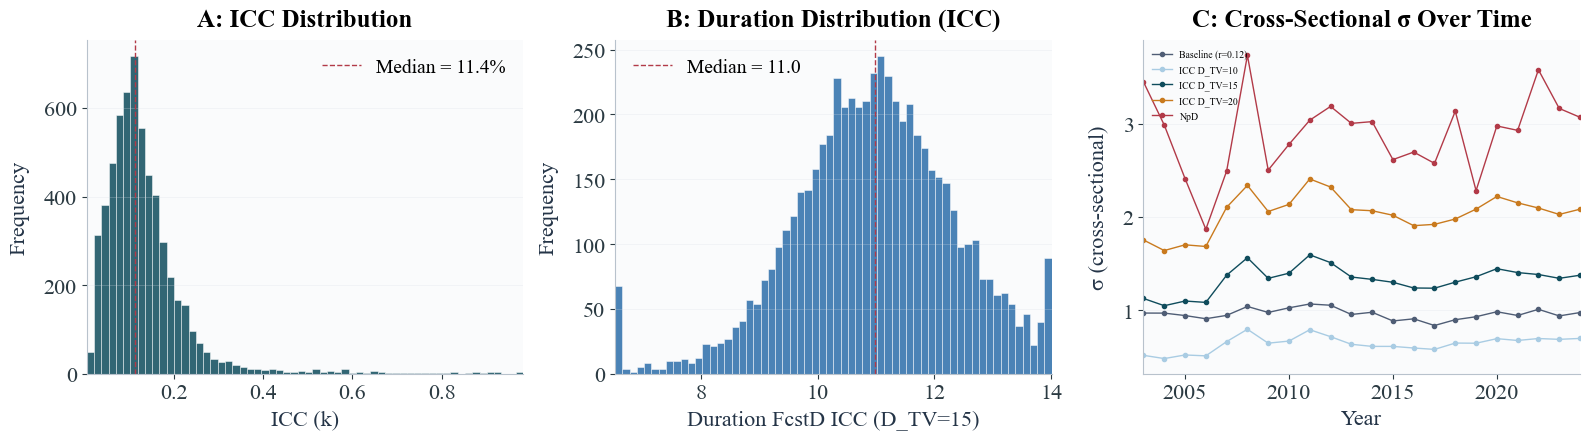

In [11]:
set_global_plot_style()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# A: ICC distribution
conv = df[df["icc_flag"] == "converged"]
axes[0].hist(conv["k_icc"], bins=60, color=COLORS["primary"], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("ICC (k)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("A: ICC Distribution")
axes[0].axvline(conv["k_icc"].median(), color=COLORS["accent"], ls="--",
                label=f'Median = {conv["k_icc"].median():.1%}')
axes[0].legend(frameon=False)
style_axes(axes[0])

# B: Duration distribution (D_TV=15)
axes[1].hist(conv["Duration_FcstD"], bins=60, color=COLORS["blue"], edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Duration FcstD ICC (D_TV=15)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("B: Duration Distribution (ICC)")
axes[1].axvline(conv["Duration_FcstD"].median(), color=COLORS["accent"], ls="--",
                label=f'Median = {conv["Duration_FcstD"].median():.1f}')
axes[1].legend(frameon=False)
style_axes(axes[1])

# C: σ over time
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
years = sorted(df["year"].unique())
for label, col, color in [
    ("Baseline (r=0.12)", "Duration_FcstD_r012", COLORS["neutral"]),
    ("ICC D_TV=10", "Duration_FcstD_DTV10", COLORS["blue_light"]),
    ("ICC D_TV=15", "Duration_FcstD", COLORS["primary"]),
    ("ICC D_TV=20", "Duration_FcstD_DTV20", COLORS["orange"]),
    ("NpD", "Duration_NetPayout", COLORS["accent"]),
]:
    if col in _mg.columns:
        ys = _mg.groupby("year")[col].std()
        axes[2].plot(ys.index, ys.values, marker="o", ms=3, label=label, color=color)
axes[2].set_xlabel("Year")
axes[2].set_ylabel("σ (cross-sectional)")
axes[2].set_title("C: Cross-Sectional σ Over Time")
axes[2].legend(frameon=False, fontsize=7)
style_axes(axes[2])

fig.tight_layout()
save_figure(fig, "icc_dtv_diagnostics")
plt.show()

In [12]:
# ==================================================================
# FcstD ICC with Fixed TV Duration — Summary
# ==================================================================
conv = df[df["icc_flag"] == "converged"]
print("=" * 70)
print("FcstD ICC with Fixed TV Duration — SUMMARY")
print("=" * 70)

# 1. Industry ROE
print("\n1. Industry ROE (trailing 5-year median):")
ind_roe = df.groupby("trbc_sector")["industry_roe_used"].agg(["mean", "median"])
print(ind_roe.to_string(float_format=lambda x: f"{x:.3f}"))

# 2. ICC distribution
k = conv["k_icc"]
print(f"\n2. ICC distribution (n={len(conv):,}):")
print(f"   Mean: {k.mean():.3%}, Median: {k.median():.3%}, "
      f"P5: {k.quantile(0.05):.3%}, P95: {k.quantile(0.95):.3%}")

# 3. Convergence
print(f"\n3. Convergence: {len(conv):,} / {len(df):,} ({len(conv)/len(df):.1%})")

# 4. D_TV comparison
print("\n4. D_TV comparison (main result):")
_np = load_parquet("EQDuration_Netpayout")[["firm_id", "date", "Duration_NetPayout"]]
_mg = df.merge(_np, on=["firm_id", "date"], how="left")
_sub = _mg[_mg["icc_flag"] == "converged"].dropna(subset=["Duration_FcstD"])
from scipy.stats import spearmanr
print(f"   {'':20s} {'D_TV=10':>10s} {'D_TV=15':>10s} {'D_TV=20':>10s} {'r=0.12':>10s}")
for metric_name, metric_fn in [
    ("avg σ", lambda c: _mg.groupby("year")[c].std().mean()),
    ("mean Duration", lambda c: _sub[c].mean()),
]:
    vals = [metric_fn(c) for c in ["Duration_FcstD_DTV10", "Duration_FcstD", "Duration_FcstD_DTV20", "Duration_FcstD_r012"]]
    print(f"   {metric_name:20s} {vals[0]:10.3f} {vals[1]:10.3f} {vals[2]:10.3f} {vals[3]:10.3f}")

for metric_name, metric_fn in [
    ("ρ(·, E/P)", lambda c: spearmanr(_sub[c], _sub["ROE_fy1"])[0]),
    ("ρ(·, NpD)", lambda c: spearmanr(_sub.dropna(subset=["Duration_NetPayout"])[c], _sub.dropna(subset=["Duration_NetPayout"])["Duration_NetPayout"])[0]),
    ("ρ(·, baseline)", lambda c: spearmanr(_sub[c], _sub["Duration_FcstD_r012"])[0]),
]:
    vals = [metric_fn(c) for c in ["Duration_FcstD_DTV10", "Duration_FcstD", "Duration_FcstD_DTV20", "Duration_FcstD_r012"]]
    print(f"   {metric_name:20s} {vals[0]:+10.3f} {vals[1]:+10.3f} {vals[2]:+10.3f} {vals[3]:+10.3f}")

# 5. TV share
print(f"\n5. TV share (ICC): mean={conv['TV_share'].mean():.1%}, "
      f"median={conv['TV_share'].median():.1%}")

print("\n" + "=" * 70)

FcstD ICC with Fixed TV Duration — SUMMARY

1. Industry ROE (trailing 5-year median):
                        mean  median
trbc_sector                         
Basic Materials        0.198   0.190
Consumer Cyclicals     0.241   0.235
Consumer Non-Cyclicals 0.219   0.207
Energy                 0.291   0.282
Financials             0.151   0.106
Healthcare             0.202   0.193
Industrials            0.235   0.233
Real Estate            0.065   0.062
Technology             0.330   0.313
Utilities              0.247   0.242

2. ICC distribution (n=5,894):
   Mean: 13.386%, Median: 11.437%, P5: 3.516%, P95: 27.410%

3. Convergence: 5,894 / 6,025 (97.8%)

4. D_TV comparison (main result):
                           D_TV=10    D_TV=15    D_TV=20     r=0.12
   avg σ                     0.640      1.327      2.035      0.960
   mean Duration             8.274     10.955     13.636      4.277
   ρ(·, E/P)                -0.332     -0.387     -0.400     +0.382
   ρ(·, NpD)                +0.2

## 7. Diagnostics

### 7.1 Sample Funnel

In [13]:
print("Sample Funnel:")
print(funnel_df.to_string(index=False))

Sample Funnel:
                        Step  Firm-years  Dropped
                   Raw input       13296        0
                year >= 2003       11232     2064
        NumAnalysts_fy1 >= 3        9736     1496
        CFPS_fy1_est not NaN        6137     3599
BE > 0 & ME > 0 & shares > 0        6025      112


### 7.2 Duration Distribution

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_distribution.png


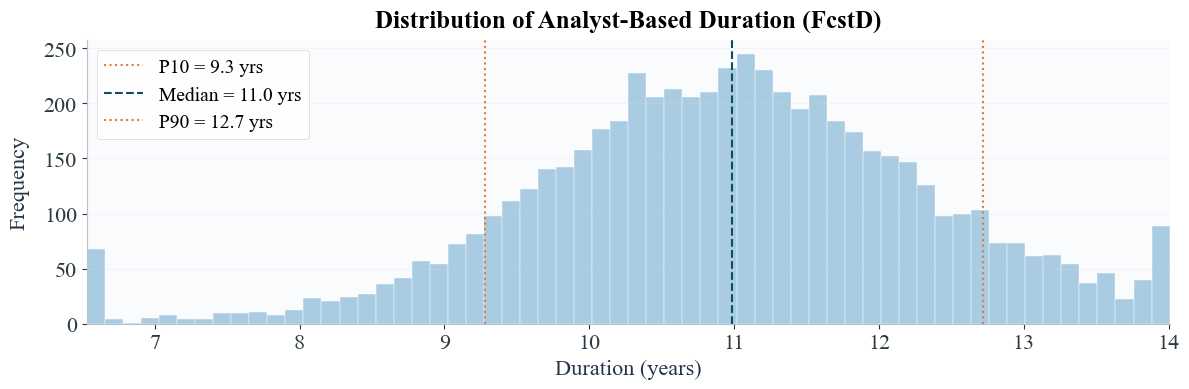

In [14]:
set_global_plot_style()

dur_plot = out.loc[~out["pv_fit_poor"], "Duration_FcstD"].dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(dur_plot, bins=60, color=COLORS["blue_light"],
        edgecolor="white", linewidth=0.3, density=False)

_p10 = dur_plot.quantile(0.10)
_p50 = dur_plot.quantile(0.50)
_p90 = dur_plot.quantile(0.90)

ax.axvline(_p10, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P10 = {_p10:.1f} yrs")
ax.axvline(_p50, color=COLORS.get("primary", "#1f4e79"),
           lw=1.5, ls="--",
           label=f"Median = {_p50:.1f} yrs")
ax.axvline(_p90, color=COLORS.get("coral", "#e07b39"),
           lw=1.5, ls=":",
           label=f"P90 = {_p90:.1f} yrs")

ax.set_title("Distribution of Analyst-Based Duration (FcstD)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("Frequency")
ax.legend(frameon=True)
style_axes(ax)
plt.tight_layout()
save_figure(fig, "duration_fcstd_distribution")
plt.show()


### 7.3 Duration Over Time

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/duration_fcstd_over_time.png


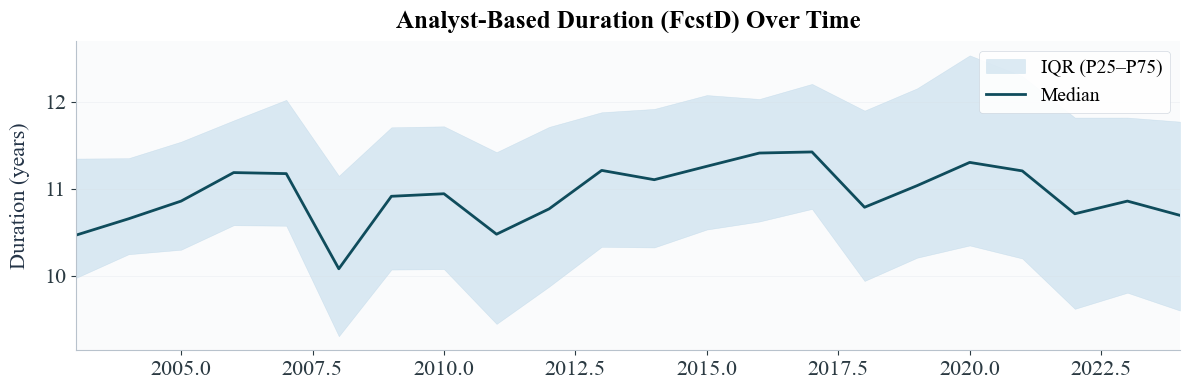

In [15]:
set_global_plot_style()

usable = out.loc[~out["pv_fit_poor"]].copy()
usable["year"] = usable["date"].dt.year

time_stats = usable.groupby("year")["Duration_FcstD"].agg(
    median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75)
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(time_stats["year"], time_stats["q25"], time_stats["q75"],
                color=COLORS["blue_light"], alpha=0.4, label="IQR (P25–P75)")
ax.plot(time_stats["year"], time_stats["median"],
        color=COLORS["primary"], lw=2.0, label="Median")

ax.set_title("Analyst-Based Duration (FcstD) Over Time")
ax.set_xlabel("")
ax.set_ylabel("Duration (years)")
ax.set_xlim(2003, usable["year"].max())
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1,1,1,0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "duration_fcstd_over_time")
plt.show()

### 7.4 Decile Analysis

We sort firms into 10 deciles by Duration_FcstD each year and report
mean duration and mean payout yield (DPS_fy1 × shares / ME) per decile.
Short-duration deciles should exhibit higher near-term payout yield.

In [16]:
dec = usable.copy()
dec["payout_yield"] = (
    dec["DPS_fy1_est"] * dec["shares_outstanding"] / dec["ME"]
)

dec["dur_decile"] = dec.groupby("year")["Duration_FcstD"].transform(
    lambda x: pd.qcut(x, 10, labels=range(1, 11), duplicates="drop")
)
dec["dur_decile"] = pd.to_numeric(dec["dur_decile"], errors="coerce")

decile_table = (
    dec.groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
        n_obs=("Duration_FcstD", "count"),
    )
    .reset_index()
)
decile_table["mean_payout_yield"] = decile_table["mean_payout_yield"] * 100  # percent

print("Decile Analysis: Duration vs Payout Yield")
print(decile_table.to_string(index=False, float_format="{:.2f}".format))

Decile Analysis: Duration vs Payout Yield
 dur_decile  mean_duration  mean_payout_yield  n_obs
          1           8.52               9.74    601
          2           9.69               4.58    585
          3          10.11               4.26    584
          4          10.47               3.62    592
          5          10.79               3.12    591
          6          11.10               2.79    581
          7          11.44               2.44    591
          8          11.86               2.06    585
          9          12.33               1.66    584
         10          13.25               0.87    600


### 7.5 Correlation with Net-Payout Duration and Fundamentals

We validate convergent validity by correlating FcstD with the net-payout
duration (Duration_NP) and fundamental variables (ME, BE/ME, E/P).

In [17]:
# Inspect columns before merge
print("out columns:", list(out.columns))
print("np_out Duration-like columns:", [c for c in np_out.columns if "uration" in c or "dur" in c.lower()])

# Merge with NetPayout duration
np_dur = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
np_dur = np_dur.rename(columns={"Duration_NetPayout": "Duration_NP"})

corr_df = out.copy()
corr_df["year"] = corr_df["date"].dt.year
corr_df = corr_df.merge(np_dur, on=["firm_id", "year"], how="left")

# Merge diagnostics
n_np_matched = corr_df["Duration_NP"].notna().sum()
n_total = len(corr_df)
print(f"\nMerge diagnostics:")
print(f"  Rows with non-null Duration_NP: {n_np_matched:,} / {n_total:,} ({n_np_matched/n_total:.1%})")

corr_usable_all = corr_df.loc[~corr_df["pv_fit_poor"]].copy()
n_usable_np = corr_usable_all["Duration_NP"].notna().sum()
n_usable = len(corr_usable_all)
print(f"  Usable FcstD sample with matched NP: {n_usable_np:,} / {n_usable:,} ({n_usable_np/n_usable:.1%})")

if n_usable_np / n_usable < 0.50:
    print(f"\n  ⚠ Coverage warning: Only {n_usable_np/n_usable:.1%} of usable FcstD firm-years")
    print(f"    have a matched NP duration. This is likely due to different sample periods")
    print(f"    or filter differences between the analyst-based and net-payout notebooks.")

# Construct additional variables
corr_df["BM"] = corr_df["BE"] / corr_df["ME"]
corr_df["EP"] = (corr_df["CFPS_fy1_est"] * corr_df["shares_outstanding"]) / corr_df["ME"]
corr_df["log_ME"] = np.log(corr_df["ME"])

# Filter usable
corr_usable = corr_df.loc[~corr_df["pv_fit_poor"]].copy()

corr_vars = ["Duration_FcstD", "Duration_NP", "log_ME", "BM", "EP"]

# Pearson
corr_matrix = corr_usable[corr_vars].corr()
print("\nPearson Correlation Matrix (usable sample):")
print(corr_matrix.to_string(float_format="{:.3f}".format))

# Spearman
spearman = corr_usable[corr_vars].corr(method="spearman")
print("\nSpearman Rank Correlation:")
print(spearman.to_string(float_format="{:.3f}".format))

# Focal correlations
both_valid = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"\nFocal: Corr(FcstD, NP) on {len(both_valid):,} overlapping firm-years:")
print(f"  Pearson:  {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP']):.3f}")
print(f"  Spearman: {both_valid['Duration_FcstD'].corr(both_valid['Duration_NP'], method='spearman'):.3f}")

out columns: ['firm_id', 'date', 'year', 'trbc_sector', 'CFPS_fy1_est', 'CFPS_fy2_est', 'CFPS_fy3_est', 'DPS_fy1_est', 'DPS_fy2_est', 'DPS_fy3_est', 'NumAnalysts_fy1', 'shares_outstanding', 'BE', 'ME', 'ROE_fy1', 'ROE_fy2', 'ROE_fy3', 'b_fy1', 'b_fy2', 'b_fy3', 'industry_roe_used', 'k_icc', 'icc_flag', 'PV_forecast', 'TV', 'TV_share', 'pv_fit_poor', 'Duration_FcstD_raw', 'Duration_FcstD', 'Duration_FcstD_DTV10_raw', 'Duration_FcstD_DTV10', 'Duration_FcstD_DTV20_raw', 'Duration_FcstD_DTV20', 'PV_forecast_r012', 'TV_r012', 'pv_fit_poor_r012', 'Duration_FcstD_r012_raw', 'Duration_FcstD_r012']
np_out Duration-like columns: ['Duration_NetPayout', 'Duration_NP_strict', 'duration_usable', 'duration_usable_strict']

Merge diagnostics:
  Rows with non-null Duration_NP: 5,039 / 6,025 (83.6%)
  Usable FcstD sample with matched NP: 4,975 / 5,894 (84.4%)

Pearson Correlation Matrix (usable sample):
                Duration_FcstD  Duration_NP  log_ME     BM     EP
Duration_FcstD           1.000     

Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/coverage_fcstd_annual.png


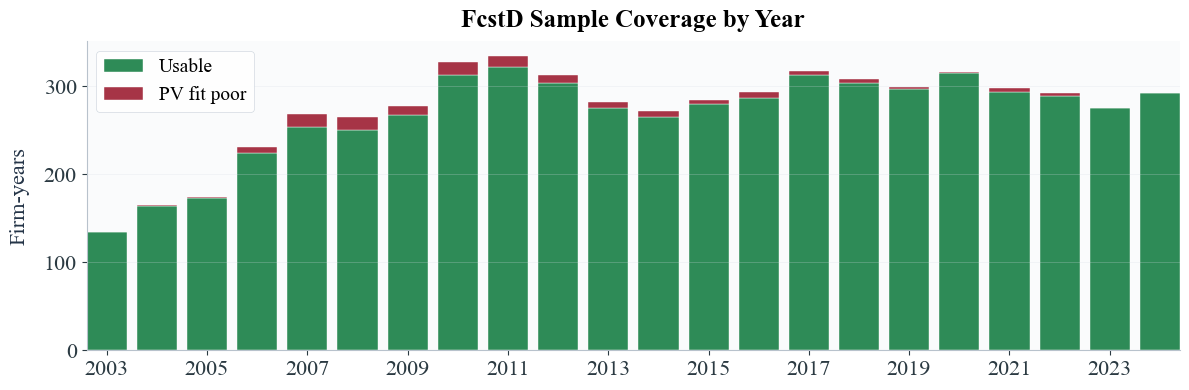

In [18]:
set_global_plot_style()

# Coverage by year: usable vs pv_fit_poor
_cov = out.copy()
_cov["year"] = _cov["date"].dt.year
_cov_grp = (
    _cov.groupby("year")
    .agg(
        usable=("pv_fit_poor", lambda s: int((~s).sum())),
        poor=("pv_fit_poor", lambda s: int(s.sum())),
    )
    .reset_index()
)
_cov_grp = _cov_grp[(_cov_grp["year"] >= 2003) & (_cov_grp["year"] <= 2024)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_cov_grp["year"], _cov_grp["usable"],
       color=COLORS["green"], edgecolor="white", linewidth=0.3,
       label="Usable")
ax.bar(_cov_grp["year"], _cov_grp["poor"],
       bottom=_cov_grp["usable"],
       color=COLORS["red"], edgecolor="white", linewidth=0.3,
       label="PV fit poor")

ax.set_title("FcstD Sample Coverage by Year")
ax.set_xlabel("")
ax.set_ylabel("Firm-years")
ax.set_xticks(range(2003, 2025, 2))
style_axes(ax)
ax.legend(loc="upper left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "coverage_fcstd_annual")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/tv_share_fcstd_hist.png


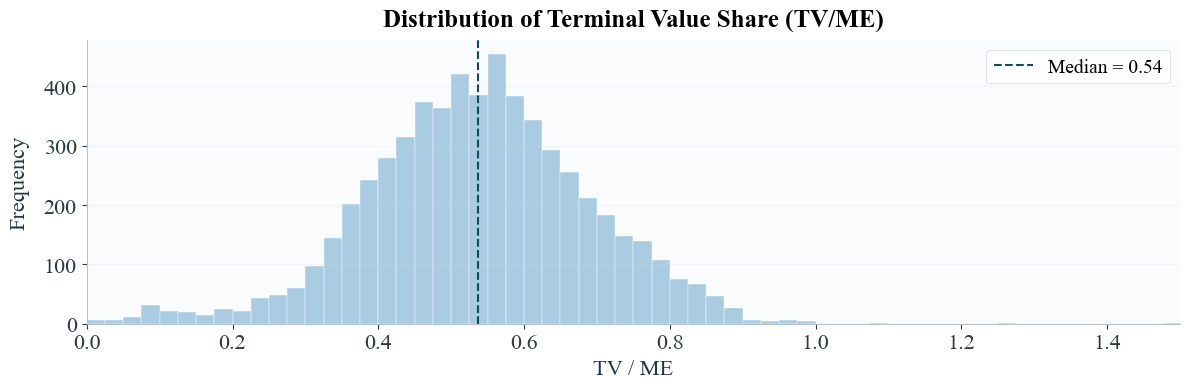

In [19]:
set_global_plot_style()

# Terminal value share: TV / ME for usable observations
_tv = out.loc[~out["pv_fit_poor"], ["TV", "ME"]].dropna()
_tv_share = (_tv["TV"] / _tv["ME"]).replace([np.inf, -np.inf], np.nan).dropna()
_tv_share_clip = _tv_share.clip(lower=0.0, upper=1.5)
_median_tv = _tv_share.median()

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(_tv_share_clip, bins=60, range=(0.0, 1.5),
        color=COLORS["blue_light"], edgecolor="white", linewidth=0.3)
ax.axvline(_median_tv, color=COLORS["primary"], lw=1.5, ls="--",
           label=f"Median = {_median_tv:.2f}")

ax.set_title("Distribution of Terminal Value Share (TV/ME)")
ax.set_xlabel("TV / ME")
ax.set_ylabel("Frequency")
ax.set_xlim(0.0, 1.5)
style_axes(ax)
ax.legend(loc="upper right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "tv_share_fcstd_hist")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_decile_payout_yield.png


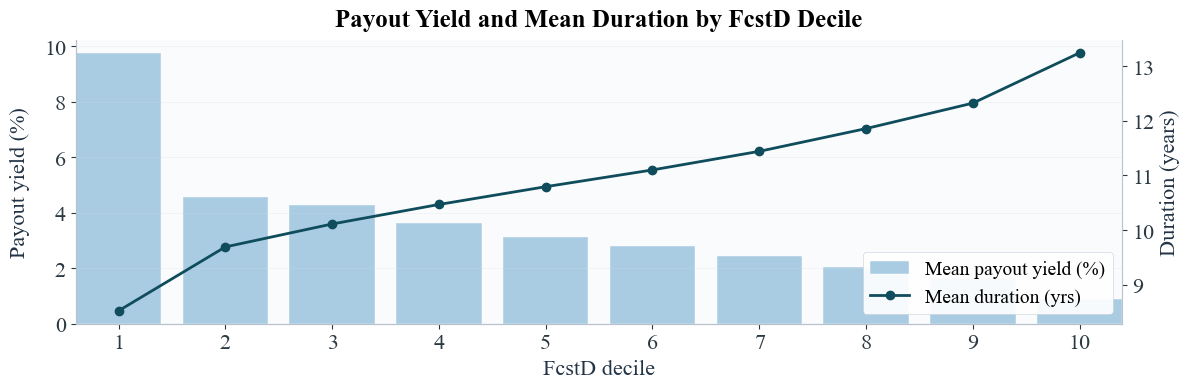

In [20]:
set_global_plot_style()

# Use existing `dec` DataFrame from Cell 22 decile analysis
_dec_plot = (
    dec.dropna(subset=["dur_decile"])
    .groupby("dur_decile")
    .agg(
        mean_duration=("Duration_FcstD", "mean"),
        mean_payout_yield=("payout_yield", "mean"),
    )
    .reset_index()
)
_dec_plot["mean_payout_yield_pct"] = _dec_plot["mean_payout_yield"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(_dec_plot["dur_decile"], _dec_plot["mean_payout_yield_pct"],
       color=COLORS["blue_light"], edgecolor="white", linewidth=0.3,
       label="Mean payout yield (%)")
ax.set_xlabel("FcstD decile")
ax.set_ylabel("Payout yield (%)")
ax.set_xticks(range(1, 11))
style_axes(ax)

ax2 = ax.twinx()
ax2.plot(_dec_plot["dur_decile"], _dec_plot["mean_duration"],
         color=COLORS["primary"], lw=2.0, marker="o",
         label="Mean duration (yrs)")
ax2.set_ylabel("Duration (years)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color("#B8C2CC")
ax2.tick_params(axis="y", labelsize=16)

ax.set_title("Payout Yield and Mean Duration by FcstD Decile")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right",
          frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_decile_payout_yield")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/fcstd_npd_scatter.png


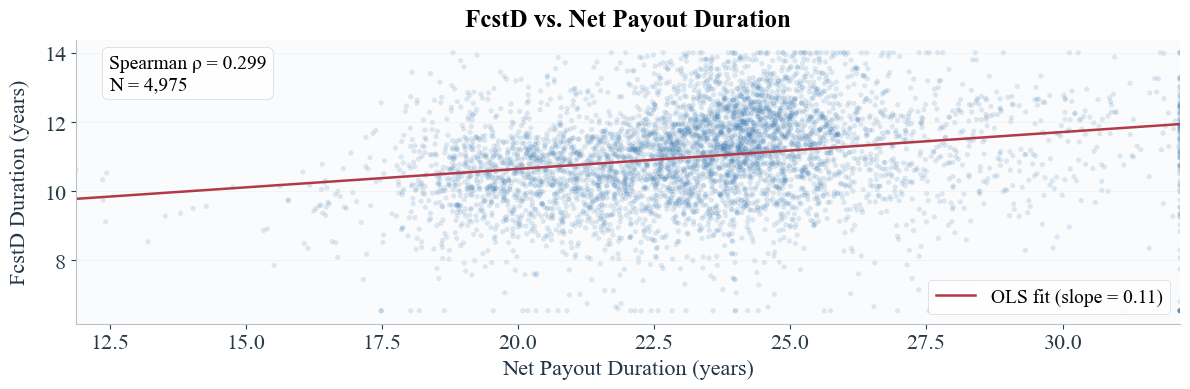

In [21]:
set_global_plot_style()

# Scatter FcstD vs NpD using corr_df from Cell 24
_sc = corr_df.loc[~corr_df["pv_fit_poor"], ["Duration_FcstD", "Duration_NP"]].dropna()

_rho_s = _sc["Duration_FcstD"].corr(_sc["Duration_NP"], method="spearman")

# Linear regression line
_x = _sc["Duration_NP"].values
_y = _sc["Duration_FcstD"].values
_slope, _intercept = np.polyfit(_x, _y, 1)
_x_line = np.linspace(_x.min(), _x.max(), 100)
_y_line = _slope * _x_line + _intercept

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(_sc["Duration_NP"], _sc["Duration_FcstD"],
           alpha=0.15, s=14, color=COLORS["blue"],
           edgecolors="none")
ax.plot(_x_line, _y_line, color=COLORS["accent"], lw=1.8,
        label=f"OLS fit (slope = {_slope:.2f})")

ax.text(0.03, 0.95,
        f"Spearman ρ = {_rho_s:.3f}\nN = {len(_sc):,}",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=14,
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor=(1, 1, 1, 0.82),
                  edgecolor="#C4CDD7"))

ax.set_title("FcstD vs. Net Payout Duration")
ax.set_xlabel("Net Payout Duration (years)")
ax.set_ylabel("FcstD Duration (years)")
style_axes(ax)
ax.legend(loc="lower right", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "fcstd_npd_scatter")
plt.show()


Saved figure: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased/roe_reversion_example.png


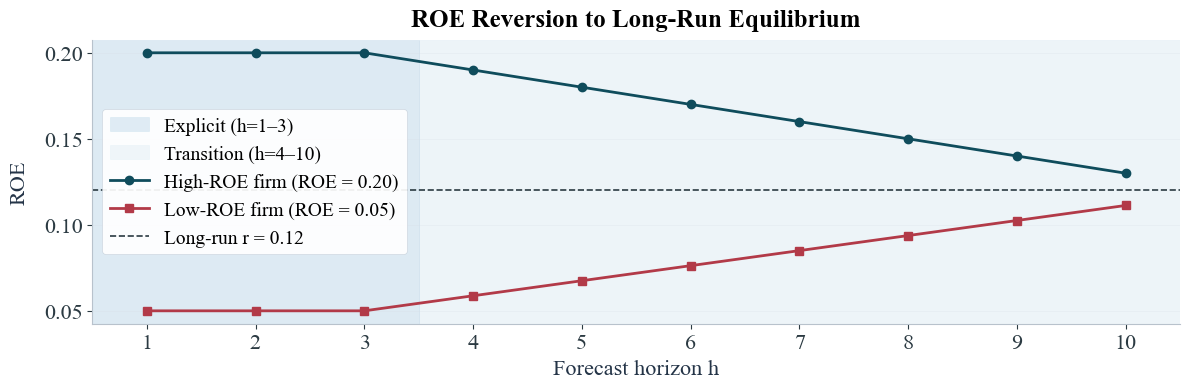

In [22]:
set_global_plot_style()

# Illustrative ROE reversion schematic
_r_bar = 0.12
_h = np.arange(1, 11)

def _roe_path(roe0: float) -> np.ndarray:
    path = np.empty_like(_h, dtype=float)
    for i, h in enumerate(_h):
        if h <= 3:
            path[i] = roe0
        else:
            alpha = (h - 3) / 8.0
            path[i] = (1 - alpha) * roe0 + alpha * _r_bar
    return path

_high = _roe_path(0.20)
_low = _roe_path(0.05)

fig, ax = plt.subplots(figsize=(12, 4))

# Shaded regions
ax.axvspan(0.5, 3.5, color=COLORS["blue_light"], alpha=0.35, label="Explicit (h=1–3)")
ax.axvspan(3.5, 10.5, color=COLORS["blue_light"], alpha=0.15, label="Transition (h=4–10)")

ax.plot(_h, _high, color=COLORS["primary"], lw=2.0, marker="o",
        label="High-ROE firm (ROE = 0.20)")
ax.plot(_h, _low, color=COLORS["accent"], lw=2.0, marker="s",
        label="Low-ROE firm (ROE = 0.05)")

ax.axhline(_r_bar, color=COLORS["reference"], lw=1.2, ls="--",
           label=f"Long-run r = {_r_bar:.2f}")

ax.set_title("ROE Reversion to Long-Run Equilibrium")
ax.set_xlabel("Forecast horizon h")
ax.set_ylabel("ROE")
ax.set_xticks(_h)
ax.set_xlim(0.5, 10.5)
style_axes(ax)
ax.legend(loc="center left", frameon=True, facecolor=(1, 1, 1, 0.82),
          edgecolor="#C4CDD7", framealpha=0.92)
plt.tight_layout()
save_figure(fig, "roe_reversion_example")
plt.show()


In [23]:
# GRAFIK-ÜBERSICHT: FcstD figures
_fcstd_figs = [
    "duration_fcstd_distribution",
    "duration_fcstd_over_time",
    "coverage_fcstd_annual",
    "tv_share_fcstd_hist",
    "fcstd_decile_payout_yield",
    "fcstd_npd_scatter",
    "roe_reversion_example",
]

print("GRAFIK-ÜBERSICHT – EQDuration_AnalystBased")
print(f"Directory: {NOTEBOOK_GRAPH_DIR}")
print("-" * 60)
for _name in _fcstd_figs:
    _p = NOTEBOOK_GRAPH_DIR / f"{_name}.png"
    _mark = "✓" if _p.exists() else "✗"
    print(f"  [{_mark}] {_name}.png")
print("-" * 60)
_n_ok = sum((NOTEBOOK_GRAPH_DIR / f"{n}.png").exists() for n in _fcstd_figs)
print(f"Total: {_n_ok}/{len(_fcstd_figs)} figures present")


GRAFIK-ÜBERSICHT – EQDuration_AnalystBased
Directory: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/EQDuration_AnalystBased
------------------------------------------------------------
  [✓] duration_fcstd_distribution.png
  [✓] duration_fcstd_over_time.png
  [✓] coverage_fcstd_annual.png
  [✓] tv_share_fcstd_hist.png
  [✓] fcstd_decile_payout_yield.png
  [✓] fcstd_npd_scatter.png
  [✓] roe_reversion_example.png
------------------------------------------------------------
Total: 7/7 figures present


## 8. Summary Statistics

In [24]:
usable_final = out.loc[~out["pv_fit_poor"]].copy()
dur = usable_final["Duration_FcstD"].dropna()

print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Output shape:       {out.shape}")
print(f"Usable firm-years:  {len(usable_final):,} / {len(out):,} ({len(usable_final)/len(out):.1%})")
print(f"pv_fit_poor rate:   {out['pv_fit_poor'].mean():.1%}")
print(f"\nWinsorization bounds: P1 = {p1_icc:.2f}, P99 = {p99_icc:.2f}")
print(f"\nDuration_FcstD percentiles (usable sample):")
for p, label in [(0.10, "P10"), (0.25, "P25"), (0.50, "P50"), (0.75, "P75"), (0.90, "P90")]:
    print(f"  {label}: {dur.quantile(p):.2f}")
print(f"  Mean: {dur.mean():.2f}")
print(f"  Std:  {dur.std():.2f}")

# Updated correlations with NP
print(f"\nCorr(Duration_FcstD, Duration_NP):")
both = corr_usable[["Duration_FcstD", "Duration_NP"]].dropna()
print(f"  Pearson:  {both['Duration_FcstD'].corr(both['Duration_NP']):.3f}")
print(f"  Spearman: {both['Duration_FcstD'].corr(both['Duration_NP'], method='spearman'):.3f}")
print(f"  (based on {len(both):,} overlapping firm-years)")

FINAL SUMMARY
Output shape:       (6025, 38)
Usable firm-years:  5,894 / 6,025 (97.8%)
pv_fit_poor rate:   2.2%

Winsorization bounds: P1 = 6.53, P99 = 14.01

Duration_FcstD percentiles (usable sample):
  P10: 9.28
  P25: 10.10
  P50: 10.99
  P75: 11.86
  P90: 12.72
  Mean: 10.96
  Std:  1.39

Corr(Duration_FcstD, Duration_NP):
  Pearson:  0.232
  Spearman: 0.299
  (based on 4,975 overlapping firm-years)


## Notes for Thesis

- **2003 start date**: Driven by I/B/E/S Cash EPS coverage in LSEG for Euro Stoxx 500.
- **BE compounding in transition zone**: Starting from h=4, book equity is compounded
  forward using the plowback rate from the last analyst year (BEG at h=3). For the
  explicit horizon (h=1–3), current-period BE_t is used as anchor, consistent with
  the short forecast horizon and data constraints.
- **Linear ROE reversion**: More conservative than AR(1) mean-reversion; avoids reliance
  on a fitted persistence parameter.
- **No LTG**: Avoids sample selection bias from LTG availability (~33% coverage).
- **pv_fit_poor flag**: Flags firm-years where the terminal value is negative (TV < 0),
  indicating that PV of forecast cash flows exceeds market equity.

## Revision Summary

Three methodological refinements were applied to the analyst-forecast-based
equity duration (FcstD) estimation:

**1. Relaxed pv_fit_poor filter.** The prior implementation flagged firm-years
as poorly fitted when either the terminal value was negative (TV < 0) or
the ratio of present-value forecasts to market equity fell below 0.25. The
latter condition was overly conservative: because book equity was used as a
static anchor, growth firms with high market equity but low current book
equity were systematically penalised, resulting in a 54.8% exclusion rate.
We retain only the TV < 0 condition, which captures economically meaningful
misfits without discarding valid observations.

**2. Forward-compounded book equity in the transition zone.** In the original
specification, current-period book equity (BE_t) served as the scaling
factor for cash flows across all ten forecast years. This understated cash
flows in the transition zone (h = 4–10) for firms with positive plowback.
We now compound BE forward from h = 4 onward using the book-equity growth
rate implied by the last analyst year (h = 3), while retaining BE_t as the
anchor for the explicit horizon (h = 1–3) where the short forecast window
justifies the static assumption.

**3. Net-payout duration merge diagnostics.** The correlation between FcstD
and net-payout duration (Duration_NP) was initially reported at approximately
−0.06. Inspection confirmed that the merge key (firm_id × year) and column
naming are correct; the low correlation reflects genuine methodological
differences between the two duration measures rather than a data error.
Detailed merge diagnostics — including coverage rates, Pearson and Spearman
correlations — are now reported to ensure transparency.

# ══════════════════════════════════════════════════════════════
# FcstD with CAPM-based firm-specific discount rate
# ══════════════════════════════════════════════════════════════

**Motivation.** The baseline FcstD uses a constant discount rate $r = 0.12$ for all firms.
This ensures all cross-sectional variation comes from earnings paths, but it also
suppresses variation from differences in systematic risk. This section re-estimates
FcstD using a CAPM-based firm-specific cost of equity:

$$r_{i,t} = r_f + \beta_{i,t} \times ERP$$

**Internally consistent:** $r_{CAPM}$ replaces $r = 0.12$ in **both** the ROE reversion
target **and** the discount factors. In steady state, $ROE \to r_{CAPM}$, so abnormal
earnings are zero — exactly as in DSS (2004) where $ROE \to r = 0.12$ and discounting
uses $r = 0.12$. The only difference is that "equilibrium" is now firm-specific.

In [25]:
# ============================================================
# 1. Load and prepare annual betas
# ============================================================
daily_ret = load_parquet("euro500_daily_returns")[["date", "firm_id", "beta"]]
daily_ret = daily_ret.dropna(subset=["beta"])
daily_ret["year"] = daily_ret["date"].dt.year

# Take the last available beta per (firm_id, year) — i.e. as of year-end
beta_annual = (
    daily_ret.sort_values("date")
    .groupby(["firm_id", "year"])["beta"]
    .last()
    .reset_index()
    .rename(columns={"beta": "beta_annual"})
)
print(f"Annual beta panel: {len(beta_annual):,} firm-years, "
      f"{beta_annual['firm_id'].nunique():,} firms, "
      f"years {beta_annual['year'].min()}–{beta_annual['year'].max()}")
print(f"  beta_annual — mean: {beta_annual['beta_annual'].mean():.3f}, "
      f"median: {beta_annual['beta_annual'].median():.3f}, "
      f"P5: {beta_annual['beta_annual'].quantile(0.05):.3f}, "
      f"P95: {beta_annual['beta_annual'].quantile(0.95):.3f}")

# ============================================================
# 2. Construct annual risk-free rate
# ============================================================
# Use rf_estr_annual from index returns, averaged within each calendar year
idx_ret = load_parquet("euro500_index_returns")[["date", "rf_estr_annual"]]
idx_ret = idx_ret.dropna(subset=["rf_estr_annual"])
idx_ret["year"] = idx_ret["date"].dt.year
rf_annual = idx_ret.groupby("year")["rf_estr_annual"].mean()
rf_annual.name = "rf_annual"
print(f"\nAnnual risk-free rate: {len(rf_annual)} years "
      f"({rf_annual.index.min()}–{rf_annual.index.max()})")
print(f"  Mean: {rf_annual.mean():.4f}, range: [{rf_annual.min():.4f}, {rf_annual.max():.4f}]")

# ============================================================
# 3. Merge betas + rf onto FcstD panel and compute CAPM DR
# ============================================================
capm = out.copy()
capm["year"] = capm["date"].dt.year

# Merge beta
capm = capm.merge(beta_annual, on=["firm_id", "year"], how="left")
n_beta_matched = capm["beta_annual"].notna().sum()
n_beta_missing = capm["beta_annual"].isna().sum()
print(f"\nBeta coverage: {n_beta_matched:,} / {len(capm):,} matched "
      f"({n_beta_matched/len(capm):.1%})")

# Impute missing betas with 1.0 (market average)
capm["beta_imputed"] = capm["beta_annual"].isna()
capm["beta_annual"] = capm["beta_annual"].fillna(1.0)
print(f"  Beta imputed (=1.0): {capm['beta_imputed'].sum():,} firm-years")

# Merge risk-free rate
capm = capm.merge(rf_annual.reset_index(), on="year", how="left")
print(f"  rf matched: {capm['rf_annual'].notna().sum():,} / {len(capm):,}")

# ============================================================
# 4. Compute CAPM discount rate for ERP = 4%, 5%, 6%
# ============================================================
ERP_LEVELS = {"": 0.05, "_ERP4": 0.04, "_ERP6": 0.06}
DR_FLOOR = 0.03
DR_CAP = 0.25

for suffix, erp in ERP_LEVELS.items():
    col = f"r_capm{suffix}"
    capm[col] = capm["rf_annual"] + capm["beta_annual"] * erp
    capm[col] = capm[col].clip(lower=DR_FLOOR, upper=DR_CAP)

# Summary stats for the baseline ERP=5%
rc = capm["r_capm"]
print(f"\nCAPM discount rate (ERP=5%):")
print(f"  Mean: {rc.mean():.4f}, Median: {rc.median():.4f}")
print(f"  P5: {rc.quantile(0.05):.4f}, P25: {rc.quantile(0.25):.4f}, "
      f"P75: {rc.quantile(0.75):.4f}, P95: {rc.quantile(0.95):.4f}")
print(f"  Floored at {DR_FLOOR:.0%}: {(capm['r_capm'] == DR_FLOOR).sum():,} obs")
print(f"  Capped at {DR_CAP:.0%}: {(capm['r_capm'] == DR_CAP).sum():,} obs")

Annual beta panel: 13,970 firm-years, 1,058 firms, years 1999–2025
  beta_annual — mean: 0.920, median: 0.855, P5: 0.060, P95: 1.971

Annual risk-free rate: 28 years (1998–2025)
  Mean: 0.0155, range: [-0.0057, 0.0439]

Beta coverage: 5,902 / 6,025 matched (98.0%)
  Beta imputed (=1.0): 123 firm-years
  rf matched: 6,025 / 6,025

CAPM discount rate (ERP=5%):
  Mean: 0.0614, Median: 0.0566
  P5: 0.0300, P25: 0.0370, P75: 0.0788, P95: 0.1134
  Floored at 3%: 990 obs
  Capped at 25%: 1 obs


In [26]:
# ============================================================
# 5. Recompute FcstD with CAPM-based discount rates
# ============================================================
# Internally consistent: r_capm replaces the constant r=0.12 in BOTH
# the ROE reversion target AND the discount factors.
# In steady state, ROE → r_capm → zero abnormal earnings (as in DSS).

H_TOTAL_C = 10
H_EXPLICIT_C = 3
H_TRANSITION_C = 7

def compute_fcstd_capm(row, dr_col="r_capm"):
    """Compute FcstD with internally consistent CAPM discount rate.
    
    Key difference from baseline: r_capm replaces the constant r=0.12
    in BOTH the ROE reversion target AND the discount factors.
    In steady state, ROE = r_capm → zero abnormal earnings.
    """
    dr = row[dr_col]
    if pd.isna(dr):
        return pd.Series({
            f"PV_forecast_{dr_col}": np.nan,
            f"TV_{dr_col}": np.nan,
            f"pv_fit_poor_{dr_col}": np.nan,
            f"Duration_{dr_col}_raw": np.nan,
        })

    BE_t = float(row["BE"])
    ME = float(row["ME"])
    shares = float(row["shares_outstanding"])

    # --- Explicit horizon (h=1..3): same cash flows as baseline ---
    cfps = [row["CFPS_fy1_est"], row["CFPS_fy2_est"], row["CFPS_fy3_est"]]
    dps  = [row["DPS_fy1_est"],  row["DPS_fy2_est"],  row["DPS_fy3_est"]]

    E = []
    for h_idx in range(H_EXPLICIT_C):
        c = cfps[h_idx]
        E.append(c * shares if pd.notna(c) else np.nan)

    ROE = []
    for h_idx in range(H_EXPLICIT_C):
        if pd.notna(E[h_idx]) and BE_t > 0:
            ROE.append(E[h_idx] / BE_t)
        else:
            ROE.append(np.nan)

    b = []
    for h_idx in range(H_EXPLICIT_C):
        d = dps[h_idx]; e = E[h_idx]
        if pd.notna(d) and pd.notna(e) and e > 0:
            b.append(np.clip((d * shares) / e, 0.0, 1.0))
        else:
            b.append(0.5)

    BEG = []
    for h_idx in range(H_EXPLICIT_C):
        if pd.notna(ROE[h_idx]):
            BEG.append(ROE[h_idx] * (1.0 - b[h_idx]))
        else:
            BEG.append(np.nan)

    CF = []
    for h_idx in range(H_EXPLICIT_C):
        if pd.notna(ROE[h_idx]) and pd.notna(BEG[h_idx]):
            CF.append(BE_t * (ROE[h_idx] - BEG[h_idx]))
        else:
            CF.append(np.nan)

    # --- Transition zone (h=4..10): ROE reverts to dr (firm-specific) ---
    ROE_last = next(
        (ROE[i] for i in reversed(range(H_EXPLICIT_C)) if pd.notna(ROE[i])),
        dr,
    )
    BEG_last = next(
        (BEG[i] for i in reversed(range(H_EXPLICIT_C)) if pd.notna(BEG[i])),
        dr * 0.5,
    )

    BE_prev = BE_t
    for h in range(4, H_TOTAL_C + 1):
        BE_h = BE_prev * (1.0 + BEG_last)
        alpha_h = (h - H_EXPLICIT_C) / H_TRANSITION_C
        ROE_h = ROE_last * (1.0 - alpha_h) + dr * alpha_h
        BEG_h = ROE_h * 0.5
        CF_h = BE_h * (ROE_h - BEG_h)
        CF.append(CF_h)
        BE_prev = BE_h

    # --- Discount factors with firm-specific CAPM rate ---
    disc_factors = [np.exp(-dr * h) for h in range(1, H_TOTAL_C + 1)]

    # --- PV of forecast cash flows ---
    PV_forecast = 0.0
    for h_idx in range(H_TOTAL_C):
        cf_h = CF[h_idx]
        if pd.notna(cf_h):
            PV_forecast += cf_h * disc_factors[h_idx]

    # --- Terminal value ---
    TV = ME - PV_forecast
    pv_fit_poor = False
    if TV < 0:
        TV = 0.0
        pv_fit_poor = True

    # --- Duration ---
    numerator = 0.0
    for h_idx in range(H_TOTAL_C):
        h = h_idx + 1
        cf_h = CF[h_idx]
        if pd.notna(cf_h):
            numerator += h * cf_h * disc_factors[h_idx]
    numerator += H_TOTAL_C * TV * disc_factors[H_TOTAL_C - 1]

    dur = numerator / ME if ME > 0 else np.nan

    return pd.Series({
        f"PV_forecast_{dr_col}": PV_forecast,
        f"TV_{dr_col}": TV,
        f"pv_fit_poor_{dr_col}": pv_fit_poor,
        f"Duration_{dr_col}_raw": dur,
    })


# --- Run for all three ERP levels ---
for suffix, erp in ERP_LEVELS.items():
    dr_col = f"r_capm{suffix}"
    print(f"Computing FcstD with CAPM DR (ERP={erp:.0%}) ...")
    res = capm.apply(compute_fcstd_capm, axis=1, dr_col=dr_col)
    capm = pd.concat([capm, res], axis=1)
    print(f"  Done. Valid: {capm[f'Duration_{dr_col}_raw'].notna().sum():,}")

# ============================================================
# 6. Winsorize all three variants
# ============================================================
for suffix, erp in ERP_LEVELS.items():
    dr_col = f"r_capm{suffix}"
    raw_col = f"Duration_{dr_col}_raw"
    poor_col = f"pv_fit_poor_{dr_col}"
    win_col = f"Duration_FcstD_CAPM{suffix}" if suffix else "Duration_FcstD_CAPM"

    usable_mask = capm[poor_col].eq(False) & capm[raw_col].notna()
    dur_usable = capm.loc[usable_mask, raw_col]
    p1_c = dur_usable.quantile(0.01)
    p99_c = dur_usable.quantile(0.99)
    capm[win_col] = capm[raw_col].clip(lower=p1_c, upper=p99_c)

    # Clean flag column name
    clean_poor = f"pv_fit_poor_capm{suffix}" if suffix else "pv_fit_poor_capm"
    capm[clean_poor] = capm[poor_col]

    n_poor = capm[poor_col].sum()
    print(f"\n{win_col} (ERP={erp:.0%}):")
    print(f"  Winsorize bounds: P1={p1_c:.2f}, P99={p99_c:.2f}")
    print(f"  TV < 0: {n_poor:.0f} ({n_poor/len(capm):.1%})")
    print(f"  Mean: {capm[win_col].mean():.2f}, Std: {capm[win_col].std():.2f}")

# Quick comparison
print("\n" + "="*60)
print("Duration comparison:")
print("="*60)
for label, col in [("FcstD baseline (r=0.12)", "Duration_FcstD_r012"),
                    ("FcstD ICC (main)", "Duration_FcstD"),
                    ("FcstD CAPM (ERP=5%)", "Duration_FcstD_CAPM"),
                    ("FcstD CAPM (ERP=4%)", "Duration_FcstD_CAPM_ERP4"),
                    ("FcstD CAPM (ERP=6%)", "Duration_FcstD_CAPM_ERP6")]:
    s = capm[col].dropna()
    print(f"  {label:30s}  mean={s.mean():.2f}  std={s.std():.2f}  "
          f"P5={s.quantile(0.05):.2f}  P95={s.quantile(0.95):.2f}")

Computing FcstD with CAPM DR (ERP=5%) ...
  Done. Valid: 6,025
Computing FcstD with CAPM DR (ERP=4%) ...
  Done. Valid: 6,025
Computing FcstD with CAPM DR (ERP=6%) ...
  Done. Valid: 6,025

Duration_FcstD_CAPM (ERP=5%):
  Winsorize bounds: P1=3.46, P99=7.30
  TV < 0: 810 (13.4%)
  Mean: 5.94, Std: 0.94

Duration_FcstD_CAPM_ERP4 (ERP=4%):
  Winsorize bounds: P1=3.92, P99=7.33
  TV < 0: 834 (13.8%)
  Mean: 6.17, Std: 0.83

Duration_FcstD_CAPM_ERP6 (ERP=6%):
  Winsorize bounds: P1=3.02, P99=7.27
  TV < 0: 779 (12.9%)
  Mean: 5.71, Std: 1.04

Duration comparison:
  FcstD baseline (r=0.12)         mean=4.32  std=0.98  P5=3.25  P95=6.37
  FcstD ICC (main)                mean=10.96  std=1.39  P5=8.71  P95=13.25
  FcstD CAPM (ERP=5%)             mean=5.94  std=0.94  P5=4.30  P95=7.30
  FcstD CAPM (ERP=4%)             mean=6.17  std=0.83  P5=4.71  P95=7.33
  FcstD CAPM (ERP=6%)             mean=5.71  std=1.04  P5=3.92  P95=7.27


## Diagnostics: FcstD Baseline vs CAPM

### A. Discount rate comparison

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/capm_dr_distribution.png


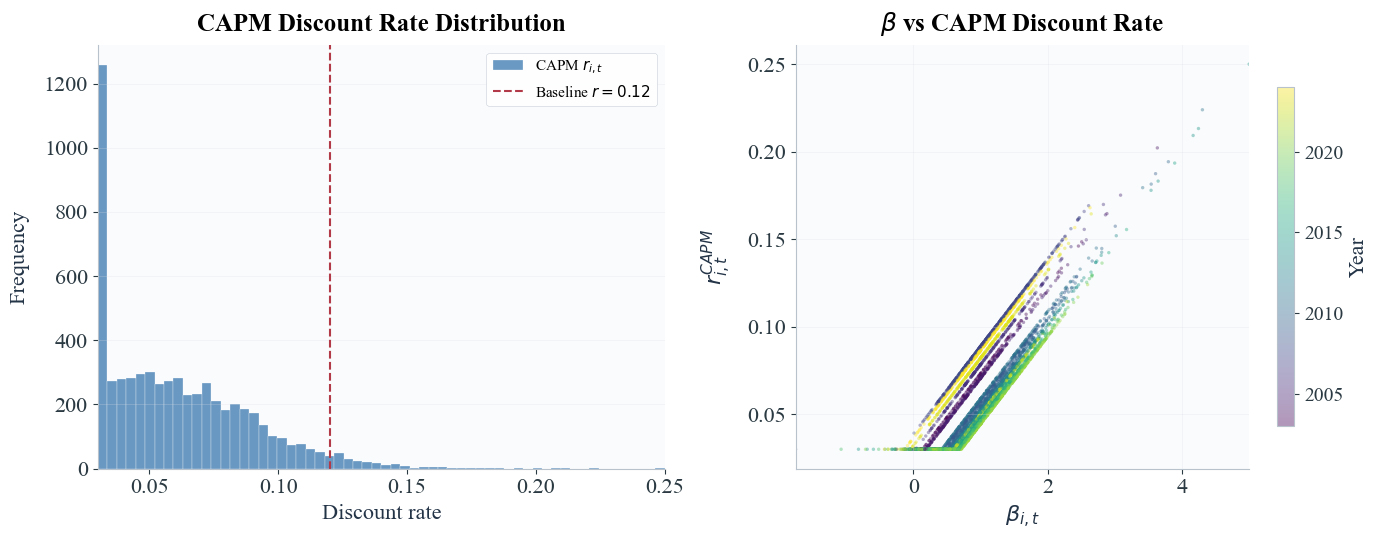


CAPM discount rate by year:
       Mean  Median     P5    P95
year                             
2003 0.0681  0.0660 0.0318 0.1141
2004 0.0642  0.0607 0.0300 0.1193
2005 0.0658  0.0650 0.0315 0.1104
2006 0.0815  0.0783 0.0428 0.1241
2007 0.0957  0.0915 0.0578 0.1444
2008 0.0944  0.0922 0.0588 0.1332
2009 0.0622  0.0575 0.0300 0.1105
2010 0.0604  0.0570 0.0300 0.1075
2011 0.0609  0.0567 0.0300 0.1091
2012 0.0510  0.0474 0.0300 0.0901
2013 0.0510  0.0472 0.0300 0.0919
2014 0.0557  0.0472 0.0300 0.1113
2015 0.0477  0.0437 0.0300 0.0812
2016 0.0457  0.0398 0.0300 0.0783
2017 0.0442  0.0392 0.0300 0.0756
2018 0.0473  0.0412 0.0300 0.0877
2019 0.0497  0.0465 0.0300 0.0856
2020 0.0519  0.0481 0.0300 0.0924
2021 0.0520  0.0477 0.0300 0.0910
2022 0.0530  0.0503 0.0300 0.0890
2023 0.0819  0.0823 0.0422 0.1202
2024 0.0869  0.0858 0.0472 0.1272


In [27]:
set_global_plot_style()

CAPM_GRAPH_DIR = GRAPH_DIR / "FcstD_CAPM"
CAPM_GRAPH_DIR.mkdir(parents=True, exist_ok=True)

def save_capm_figure(fig, name: str):
    path = CAPM_GRAPH_DIR / f"{name}.png"
    _ps_save_figure(fig, path, dpi=220)
    print(f"Saved: {path}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Panel A: Histogram of r_capm vs constant 0.12 ---
ax = axes[0]
ax.hist(capm["r_capm"].dropna(), bins=60, color=COLORS["blue"], alpha=0.7,
        edgecolor="white", linewidth=0.3, label="CAPM $r_{i,t}$")
ax.axvline(0.12, color=COLORS["accent"], ls="--", lw=1.5, label="Baseline $r = 0.12$")
ax.set_xlabel("Discount rate")
ax.set_ylabel("Frequency")
ax.set_title("CAPM Discount Rate Distribution")
style_axes(ax)
ax.legend(fontsize=11)

# --- Panel B: Scatter beta vs r_capm ---
ax = axes[1]
sc = ax.scatter(capm["beta_annual"], capm["r_capm"], c=capm["year"],
                cmap="viridis", s=6, alpha=0.4, edgecolors="none")
ax.set_xlabel(r"$\beta_{i,t}$")
ax.set_ylabel(r"$r_{i,t}^{CAPM}$")
ax.set_title(r"$\beta$ vs CAPM Discount Rate")
style_axes(ax, grid_axis="both")
fig.colorbar(sc, ax=ax, label="Year", shrink=0.8)

fig.tight_layout()
save_capm_figure(fig, "capm_dr_distribution")
plt.show()

# Summary stats by year
dr_by_year = capm.groupby("year")["r_capm"].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
)[["mean", "50%", "5%", "95%"]]
dr_by_year.columns = ["Mean", "Median", "P5", "P95"]
print("\nCAPM discount rate by year:")
print(dr_by_year.to_string(float_format="{:.4f}".format))

### B. Cross-sectional variation (key test)

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/sigma_comparison.png


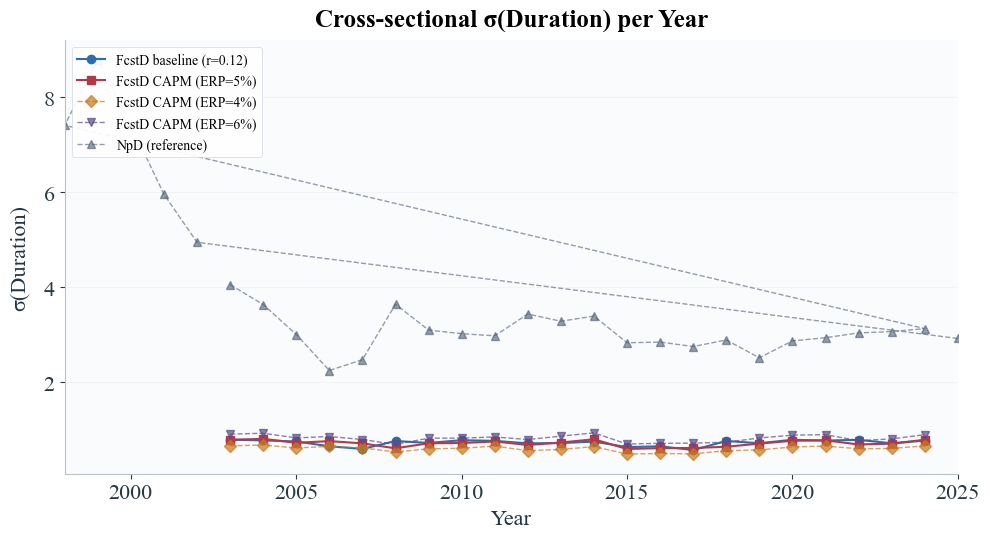


Average σ(Duration) across years:
  FcstD baseline (r=0.12):  σ = 0.721
  FcstD CAPM (ERP=5%):      σ = 0.709  (ratio: 0.98×)
  FcstD CAPM (ERP=4%):      σ = 0.595  (ratio: 0.83×)
  FcstD CAPM (ERP=6%):      σ = 0.816  (ratio: 1.13×)
  NpD (reference):           σ = 3.732


In [28]:
set_global_plot_style()

# --- Compute yearly sigma for all variants ---
usable_base = capm.loc[~capm["pv_fit_poor_r012"]].copy()
sigma_base = usable_base.groupby("year")["Duration_FcstD_r012"].std().rename("σ(FcstD baseline)")

usable_capm = capm.loc[capm["pv_fit_poor_capm"].eq(False) & capm["Duration_FcstD_CAPM"].notna()]
sigma_capm = usable_capm.groupby("year")["Duration_FcstD_CAPM"].std().rename("σ(FcstD CAPM)")

usable_erp4 = capm.loc[capm["pv_fit_poor_capm_ERP4"].eq(False) & capm["Duration_FcstD_CAPM_ERP4"].notna()]
sigma_erp4 = usable_erp4.groupby("year")["Duration_FcstD_CAPM_ERP4"].std().rename("σ(FcstD CAPM ERP4)")

usable_erp6 = capm.loc[capm["pv_fit_poor_capm_ERP6"].eq(False) & capm["Duration_FcstD_CAPM_ERP6"].notna()]
sigma_erp6 = usable_erp6.groupby("year")["Duration_FcstD_CAPM_ERP6"].std().rename("σ(FcstD CAPM ERP6)")

# NpD reference
np_dur_ref = np_out.loc[np_out["duration_usable"] == True].copy()
sigma_npd = np_dur_ref.groupby("year")["Duration_NetPayout"].std().rename("σ(NpD)")

sigma_df = pd.concat([sigma_base, sigma_capm, sigma_erp4, sigma_erp6, sigma_npd], axis=1).dropna(how="all")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(sigma_df.index, sigma_df["σ(FcstD baseline)"], "o-",
        color=COLORS["blue"], label="FcstD baseline (r=0.12)", lw=1.5)
ax.plot(sigma_df.index, sigma_df["σ(FcstD CAPM)"], "s-",
        color=COLORS["accent"], label="FcstD CAPM (ERP=5%)", lw=1.5)
ax.plot(sigma_df.index, sigma_df["σ(FcstD CAPM ERP4)"], "D--",
        color=COLORS["orange"], label="FcstD CAPM (ERP=4%)", lw=1.0, alpha=0.7)
ax.plot(sigma_df.index, sigma_df["σ(FcstD CAPM ERP6)"], "v--",
        color=COLORS["purple"], label="FcstD CAPM (ERP=6%)", lw=1.0, alpha=0.7)
ax.plot(sigma_df.index, sigma_df["σ(NpD)"], "^--",
        color=COLORS["neutral"], label="NpD (reference)", lw=1.0, alpha=0.6)
ax.set_title("Cross-sectional σ(Duration) per Year")
ax.set_ylabel("σ(Duration)")
ax.set_xlabel("Year")
style_axes(ax)
ax.legend(fontsize=10, loc="upper left")
fig.tight_layout()
save_capm_figure(fig, "sigma_comparison")
plt.show()

# Print averages and ratios
avg_base = sigma_base.mean()
avg_capm = sigma_capm.mean()
avg_erp4 = sigma_erp4.mean()
avg_erp6 = sigma_erp6.mean()
avg_npd = sigma_npd.mean()

print("\nAverage σ(Duration) across years:")
print(f"  FcstD baseline (r=0.12):  σ = {avg_base:.3f}")
print(f"  FcstD CAPM (ERP=5%):      σ = {avg_capm:.3f}  (ratio: {avg_capm/avg_base:.2f}×)")
print(f"  FcstD CAPM (ERP=4%):      σ = {avg_erp4:.3f}  (ratio: {avg_erp4/avg_base:.2f}×)")
print(f"  FcstD CAPM (ERP=6%):      σ = {avg_erp6:.3f}  (ratio: {avg_erp6/avg_base:.2f}×)")
print(f"  NpD (reference):           σ = {avg_npd:.3f}")

### C. Distribution comparison

Observations with both variants (usable): 5,215
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/distribution_comparison.png


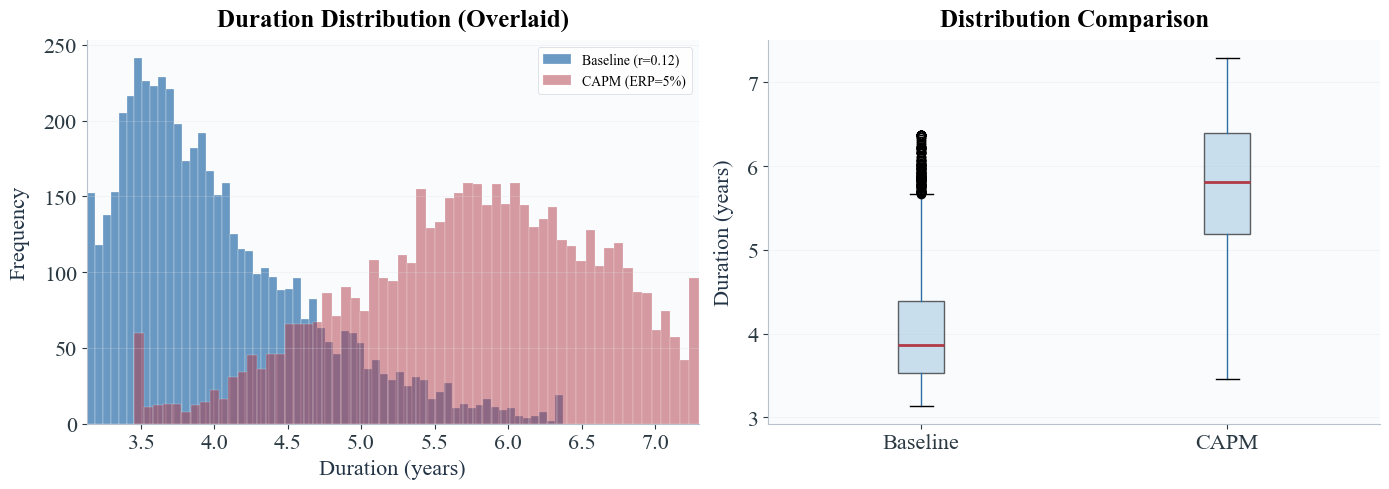


Summary Statistics: FcstD Baseline vs FcstD CAPM
       FcstD baseline  FcstD CAPM
count        5215.000    5215.000
mean            4.021       5.754
std             0.650       0.853
min             3.132       3.456
1%              3.132       3.456
5%              3.233       4.248
25%             3.529       5.189
50%             3.868       5.812
75%             4.383       6.396
95%             5.339       7.045
99%             5.994       7.296
max             6.372       7.296
IQR             0.854       1.206


In [29]:
set_global_plot_style()

both = capm.loc[
    capm["Duration_FcstD_r012"].notna()
    & capm["Duration_FcstD_CAPM"].notna()
    & ~capm["pv_fit_poor_r012"]
    & capm["pv_fit_poor_capm"].eq(False)
].copy()
print(f"Observations with both variants (usable): {len(both):,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histogram
ax = axes[0]
ax.hist(both["Duration_FcstD_r012"], bins=60, color=COLORS["blue"], alpha=0.7,
        edgecolor="white", linewidth=0.3, label="Baseline (r=0.12)")
ax.hist(both["Duration_FcstD_CAPM"], bins=60, color=COLORS["accent"], alpha=0.5,
        edgecolor="white", linewidth=0.3, label="CAPM (ERP=5%)")
ax.set_title("Duration Distribution (Overlaid)")
ax.set_xlabel("Duration (years)")
ax.set_ylabel("Frequency")
style_axes(ax)
ax.legend(fontsize=10)

# Boxplot
ax = axes[1]
bp_data = both[["Duration_FcstD_r012", "Duration_FcstD_CAPM"]].rename(
    columns={"Duration_FcstD_r012": "Baseline", "Duration_FcstD_CAPM": "CAPM"})
bp_data.boxplot(ax=ax, grid=False, patch_artist=True,
                boxprops=dict(facecolor=COLORS["blue_light"], alpha=0.6),
                medianprops=dict(color=COLORS["accent"], lw=2))
ax.set_title("Distribution Comparison")
ax.set_ylabel("Duration (years)")
style_axes(ax)

fig.tight_layout()
save_capm_figure(fig, "distribution_comparison")
plt.show()

# Summary stats
print("\n" + "="*70)
print("Summary Statistics: FcstD Baseline vs FcstD CAPM")
print("="*70)
stats = pd.DataFrame({
    "FcstD baseline": both["Duration_FcstD_r012"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]),
    "FcstD CAPM": both["Duration_FcstD_CAPM"].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]),
})
stats.loc["IQR"] = stats.loc["75%"] - stats.loc["25%"]
print(stats.to_string(float_format="{:.3f}".format))

### D. Correlation structure

In [30]:
from scipy.stats import spearmanr

# Merge NpD duration
np_dur_corr = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
np_dur_corr = np_dur_corr.rename(columns={"Duration_NetPayout": "Duration_NP"})
capm_corr = capm.merge(np_dur_corr, on=["firm_id", "year"], how="left")

# Add B/M and E/P
capm_corr["BM"] = capm_corr["BE"] / capm_corr["ME"]
capm_corr["EP"] = capm_corr["ROE_fy1"] * capm_corr["BE"] / capm_corr["ME"]

# Filter to usable obs with all three durations
mask_corr = (
    capm_corr["Duration_FcstD_r012"].notna()
    & capm_corr["Duration_FcstD_CAPM"].notna()
    & capm_corr["Duration_NP"].notna()
    & ~capm_corr["pv_fit_poor_r012"]
    & capm_corr["pv_fit_poor_capm"].eq(False)
)
trip = capm_corr.loc[mask_corr].copy()
print(f"Triple-valid observations: {len(trip):,}")

# Spearman correlation matrix
corr_cols = ["Duration_FcstD_r012", "Duration_FcstD_CAPM", "Duration_NP", "BM", "EP"]
corr_labels = ["FcstD baseline", "FcstD CAPM", "NpD", "B/M", "E/P"]
corr_data = trip[corr_cols].dropna()
corr_matrix = corr_data.corr(method="spearman")
corr_matrix.index = corr_labels
corr_matrix.columns = corr_labels
print("\nSpearman correlation matrix:")
print(corr_matrix.to_string(float_format="{:+.3f}".format))

# Key correlations
rho_base_npd, _ = spearmanr(trip["Duration_FcstD_r012"], trip["Duration_NP"])
rho_capm_npd, _ = spearmanr(trip["Duration_FcstD_CAPM"], trip["Duration_NP"])
rho_base_capm, _ = spearmanr(trip["Duration_FcstD_r012"], trip["Duration_FcstD_CAPM"])

print(f"\nKey Spearman correlations (n={len(trip):,}):")
print(f"  Baseline vs NpD:     ρ = {rho_base_npd:+.3f}")
print(f"  CAPM vs NpD:         ρ = {rho_capm_npd:+.3f}")
print(f"  Baseline vs CAPM:    ρ = {rho_base_capm:+.3f}")

if abs(rho_capm_npd) > abs(rho_base_npd):
    print(f"\n  → CAPM variant has STRONGER correlation with NpD "
          f"(|{rho_capm_npd:.3f}| > |{rho_base_npd:.3f}|)")
else:
    print(f"\n  → CAPM variant has WEAKER correlation with NpD "
          f"(|{rho_capm_npd:.3f}| ≤ |{rho_base_npd:.3f}|)")

Triple-valid observations: 4,383

Spearman correlation matrix:
                FcstD baseline  FcstD CAPM    NpD    B/M    E/P
FcstD baseline          +1.000      -0.148 -0.285 +0.500 +0.812
FcstD CAPM              -0.148      +1.000 +0.125 -0.171 -0.223
NpD                     -0.285      +0.125 +1.000 -0.270 -0.367
B/M                     +0.500      -0.171 -0.270 +1.000 +0.546
E/P                     +0.812      -0.223 -0.367 +0.546 +1.000

Key Spearman correlations (n=4,383):
  Baseline vs NpD:     ρ = -0.285
  CAPM vs NpD:         ρ = +0.125
  Baseline vs CAPM:    ρ = -0.148

  → CAPM variant has WEAKER correlation with NpD (|0.125| ≤ |-0.285|)


### E. Scatter: Baseline vs CAPM

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/scatter_baseline_vs_capm.png


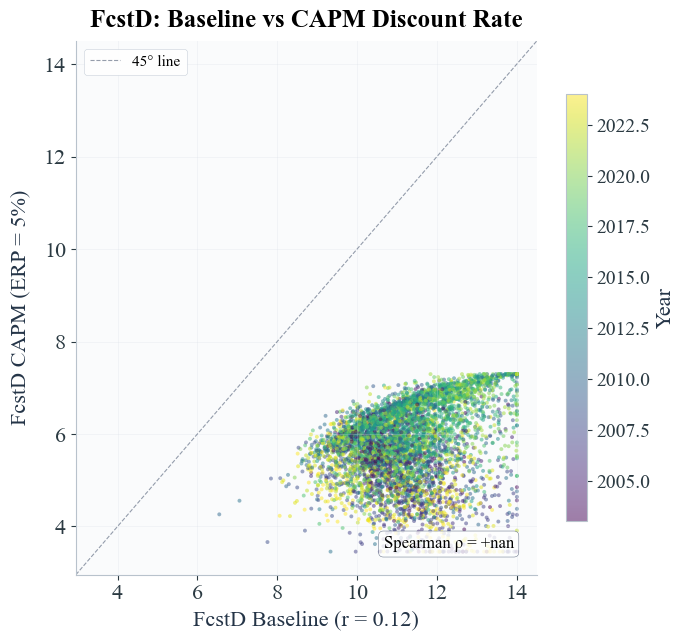

In [31]:
set_global_plot_style()

fig, ax = plt.subplots(figsize=(7, 6.5))
sc = ax.scatter(
    both["Duration_FcstD"], both["Duration_FcstD_CAPM"],
    c=both["year"], cmap="viridis", s=8, alpha=0.5, edgecolors="none")
lims = [
    min(both["Duration_FcstD"].min(), both["Duration_FcstD_CAPM"].min()) - 0.5,
    max(both["Duration_FcstD"].max(), both["Duration_FcstD_CAPM"].max()) + 0.5,
]
ax.plot(lims, lims, "--", color=COLORS["neutral"], lw=0.8, alpha=0.6, label="45° line")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("FcstD Baseline (r = 0.12)")
ax.set_ylabel("FcstD CAPM (ERP = 5%)")
ax.set_title("FcstD: Baseline vs CAPM Discount Rate")
style_axes(ax, grid_axis="both")
ax.legend(fontsize=11, loc="upper left")
fig.colorbar(sc, ax=ax, label="Year", shrink=0.8)

# Annotate Spearman rho
rho_sc, _ = spearmanr(both["Duration_FcstD"], both["Duration_FcstD_CAPM"])
ax.annotate(f"Spearman ρ = {rho_sc:+.3f}",
            xy=(0.95, 0.05), xycoords="axes fraction", ha="right", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["neutral"], alpha=0.8))

fig.tight_layout()
save_capm_figure(fig, "scatter_baseline_vs_capm")
plt.show()

### F. ERP sensitivity

In [32]:
# ERP sensitivity table
erp_results = []
for label, dur_col, poor_col_name in [
    ("ERP=4%", "Duration_FcstD_CAPM_ERP4", "pv_fit_poor_capm_ERP4"),
    ("ERP=5%", "Duration_FcstD_CAPM", "pv_fit_poor_capm"),
    ("ERP=6%", "Duration_FcstD_CAPM_ERP6", "pv_fit_poor_capm_ERP6"),
]:
    mask_u = capm[poor_col_name].eq(False) & capm[dur_col].notna()
    s_yr = capm.loc[mask_u].groupby("year")[dur_col].std()
    avg_sigma_erp = s_yr.mean()

    # Spearman with NpD
    merged = capm_corr.loc[
        capm_corr[dur_col].notna() & capm_corr["Duration_NP"].notna()
    ]
    rho_npd_e, _ = spearmanr(merged[dur_col], merged["Duration_NP"])

    # Spearman with baseline
    merged_b = capm.loc[capm[dur_col].notna() & capm["Duration_FcstD_r012"].notna()]
    rho_base_e, _ = spearmanr(merged_b[dur_col], merged_b["Duration_FcstD_r012"])

    erp_results.append({
        "ERP": label,
        "Avg σ": avg_sigma_erp,
        "σ ratio (vs baseline)": avg_sigma_erp / avg_base,
        "ρ(NpD)": rho_npd_e,
        "ρ(baseline)": rho_base_e,
    })

erp_df = pd.DataFrame(erp_results).set_index("ERP")
print("ERP Sensitivity:")
print(erp_df.to_string(float_format="{:.3f}".format))

ERP Sensitivity:
        Avg σ  σ ratio (vs baseline)  ρ(NpD)  ρ(baseline)
ERP                                                      
ERP=4%  0.595                  0.825   0.073        0.181
ERP=5%  0.709                  0.985   0.063        0.240
ERP=6%  0.816                  1.132   0.052        0.286


## Save Output

In [ ]:
# CAPM save removed — no longer needed
pass

## FcstD CAPM — Summary

In [34]:
print("=" * 70)
print("FcstD CAPM DISCOUNT RATE — SUMMARY")
print("=" * 70)

rc = capm["r_capm"]
print(f"\n1. CAPM discount rate distribution:")
print(f"   Mean: {rc.mean():.2%}, Median: {rc.median():.2%}, "
      f"P5–P95: {rc.quantile(0.05):.2%} – {rc.quantile(0.95):.2%}")
print(f"   Beta imputed (=1.0): {capm['beta_imputed'].sum():,} firm-years "
      f"({capm['beta_imputed'].mean():.1%})")
print(f"   DR floored at 3%: {(capm['r_capm'] == 0.03).sum():,} obs | "
      f"DR capped at 25%: {(capm['r_capm'] == 0.25).sum():,} obs")

print(f"\n2. Cross-sectional variation (average σ across years):")
print(f"   FcstD baseline (r=0.12):  σ = {avg_base:.3f}")
print(f"   FcstD CAPM (ERP=5%):      σ = {avg_capm:.3f}  (ratio: {avg_capm/avg_base:.2f}×)")
print(f"   FcstD CAPM (ERP=4%):      σ = {avg_erp4:.3f}  (ratio: {avg_erp4/avg_base:.2f}×)")
print(f"   FcstD CAPM (ERP=6%):      σ = {avg_erp6:.3f}  (ratio: {avg_erp6/avg_base:.2f}×)")
print(f"   NpD (reference):           σ = {avg_npd:.3f}")

print(f"\n3. Spearman correlations:")
print(f"   Baseline vs NpD:     ρ = {rho_base_npd:+.3f}")
print(f"   CAPM vs NpD:         ρ = {rho_capm_npd:+.3f}")
print(f"   Baseline vs CAPM:    ρ = {rho_base_capm:+.3f}")

tv_poor_base = capm["pv_fit_poor_r012"].mean()
tv_poor_capm = capm["pv_fit_poor_capm"].mean()
print(f"\n4. TV < 0 rates:")
print(f"   Baseline: {tv_poor_base:.1%} | CAPM: {tv_poor_capm:.1%}")

ratio = avg_capm / avg_base
if ratio > 1.3:
    verdict = ("STRONG EVIDENCE that the constant DR suppresses variation. "
               "The CAPM-based FcstD is recommended for regressions.")
elif ratio > 1.1:
    verdict = ("MODERATE EVIDENCE of variation improvement. "
               "CAPM-based FcstD may improve regression power.")
else:
    verdict = ("WEAK EVIDENCE — the CAPM DR does not substantially increase "
               "cross-sectional variation. The improvement is marginal.")
print(f"\n5. Verdict: {verdict}")
print("=" * 70)

FcstD CAPM DISCOUNT RATE — SUMMARY

1. CAPM discount rate distribution:
   Mean: 6.14%, Median: 5.66%, P5–P95: 3.00% – 11.34%
   Beta imputed (=1.0): 123 firm-years (2.0%)
   DR floored at 3%: 990 obs | DR capped at 25%: 1 obs

2. Cross-sectional variation (average σ across years):
   FcstD baseline (r=0.12):  σ = 0.721
   FcstD CAPM (ERP=5%):      σ = 0.709  (ratio: 0.98×)
   FcstD CAPM (ERP=4%):      σ = 0.595  (ratio: 0.83×)
   FcstD CAPM (ERP=6%):      σ = 0.816  (ratio: 1.13×)
   NpD (reference):           σ = 3.732

3. Spearman correlations:
   Baseline vs NpD:     ρ = -0.285
   CAPM vs NpD:         ρ = +0.125
   Baseline vs CAPM:    ρ = -0.148

4. TV < 0 rates:
   Baseline: 10.4% | CAPM: 13.4%

5. Verdict: WEAK EVIDENCE — the CAPM DR does not substantially increase cross-sectional variation. The improvement is marginal.


# ══════════════════════════════════════════════════════════════
# Diagnostic: What does FcstD Baseline actually measure?
# ══════════════════════════════════════════════════════════════

**Hypothesis.** FcstD baseline ($r = 0.12$) correlates $\rho = +0.79$ with E/P,
suggesting it is essentially a repackaged earnings yield. The high constant DR (12%)
discounts explicit cash flows so aggressively that the Terminal Value dominates the
duration calculation. Since TV $= ME - PV_{forecast}$ and $PV_{forecast}$ is small,
TV $\approx ME$, and duration $\approx 10 \cdot ME \cdot \delta_{10} / ME \approx 10 \cdot e^{-1.2} \approx 3.0$
for all firms regardless of their earnings forecasts.

The CAPM variant ($r \approx 6\%$) should give much more weight to explicit cash flows,
breaking this E/P redundancy.

In [35]:
# ============================================================
# 1. TV Share of Duration: Back-calculation from existing columns
# ============================================================
# Duration = (Explicit_dur + TV_dur) / ME
# TV_dur = H_TOTAL * TV * exp(-r * H_TOTAL)
# Explicit_dur = Duration_raw * ME - TV_dur

H_TOT = 10

# --- Baseline (r=0.12) ---
r_base = 0.12
tv_dur_base = H_TOT * out["TV_r012"] * np.exp(-r_base * H_TOT)
total_dur_num_base = out["Duration_FcstD_r012_raw"] * out["ME"]
expl_dur_base = total_dur_num_base - tv_dur_base

# TV share of total duration numerator
capm["TV_share_base"] = tv_dur_base.values / total_dur_num_base.values

# --- CAPM (r=r_capm, firm-specific) ---
# TV_r_capm and Duration_r_capm_raw are in the capm DataFrame from cell 37
tv_dur_capm = H_TOT * capm["TV_r_capm"] * np.exp(-capm["r_capm"] * H_TOT)
total_dur_num_capm = capm["Duration_r_capm_raw"] * capm["ME"]
expl_dur_capm = total_dur_num_capm - tv_dur_capm

capm["TV_share_capm"] = tv_dur_capm / total_dur_num_capm

# Filter to usable observations (both variants available, TV >= 0)
usable_tv = capm.loc[
    ~capm["pv_fit_poor_r012"]
    & capm["pv_fit_poor_capm"].eq(False)
    & capm["TV_share_base"].notna()
    & capm["TV_share_capm"].notna()
    & np.isfinite(capm["TV_share_base"])
    & np.isfinite(capm["TV_share_capm"])
].copy()

print(f"Usable firm-years for TV share analysis: {len(usable_tv):,}")
print(f"\nTV Share of Duration:")
print(f"  {'':30s}  {'Baseline (r=0.12)':>20s}  {'CAPM (r=r_capm)':>20s}")
for stat, fn in [("Mean", "mean"), ("Median", "median"),
                  ("P10", lambda s: s.quantile(0.10)),
                  ("P90", lambda s: s.quantile(0.90))]:
    if callable(fn):
        v_b = fn(usable_tv["TV_share_base"])
        v_c = fn(usable_tv["TV_share_capm"])
    else:
        v_b = getattr(usable_tv["TV_share_base"], fn)()
        v_c = getattr(usable_tv["TV_share_capm"], fn)()
    print(f"  {stat:30s}  {v_b:20.3f}  {v_c:20.3f}")

Usable firm-years for TV share analysis: 5,215

TV Share of Duration:
                                     Baseline (r=0.12)       CAPM (r=r_capm)
  Mean                                           0.513                 0.590
  Median                                         0.525                 0.624
  P10                                            0.230                 0.250
  P90                                            0.773                 0.867


### Plot A: TV Share histograms

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/tv_share_histograms.png


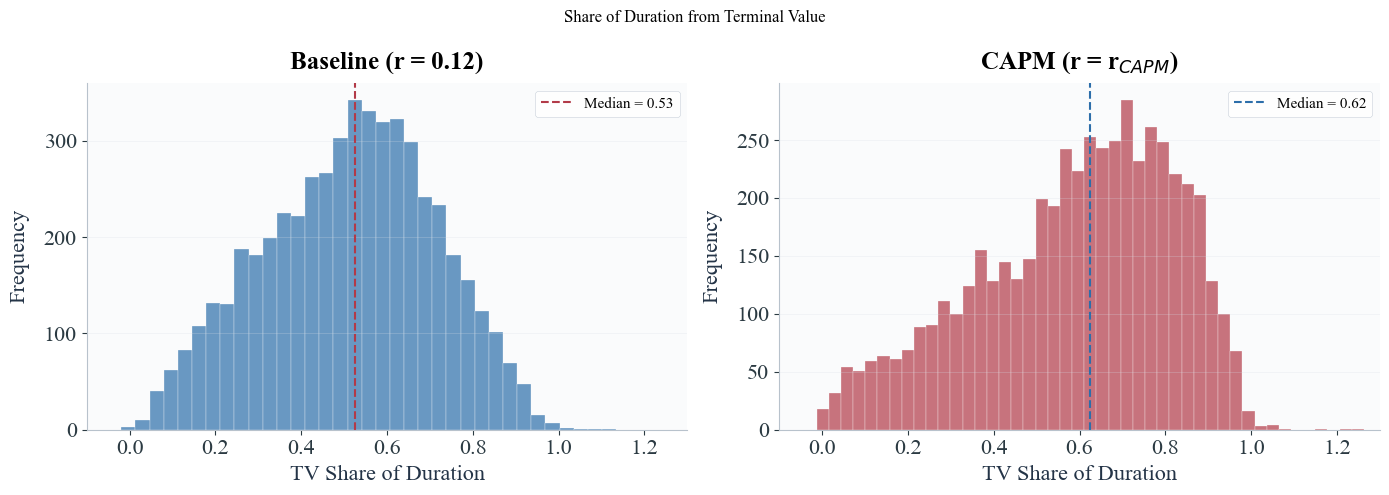

In [36]:
set_global_plot_style()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(usable_tv["TV_share_base"], bins=60, color=COLORS["blue"], alpha=0.7,
        edgecolor="white", linewidth=0.3)
ax.axvline(usable_tv["TV_share_base"].median(), color=COLORS["accent"],
           ls="--", lw=1.5, label=f'Median = {usable_tv["TV_share_base"].median():.2f}')
ax.set_title("Baseline (r = 0.12)")
ax.set_xlabel("TV Share of Duration")
ax.set_ylabel("Frequency")
ax.set_xlim(-0.1, 1.3)
style_axes(ax)
ax.legend(fontsize=11)

ax = axes[1]
ax.hist(usable_tv["TV_share_capm"], bins=60, color=COLORS["accent"], alpha=0.7,
        edgecolor="white", linewidth=0.3)
ax.axvline(usable_tv["TV_share_capm"].median(), color=COLORS["blue"],
           ls="--", lw=1.5, label=f'Median = {usable_tv["TV_share_capm"].median():.2f}')
ax.set_title("CAPM (r = r$_{CAPM}$)")
ax.set_xlabel("TV Share of Duration")
ax.set_ylabel("Frequency")
ax.set_xlim(-0.1, 1.3)
style_axes(ax)
ax.legend(fontsize=11)

fig.suptitle("Share of Duration from Terminal Value", fontsize=16, y=1.02)
fig.tight_layout()
save_capm_figure(fig, "tv_share_histograms")
plt.show()

### Plot B: TV Share vs E/P

Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/tv_share_vs_ep.png


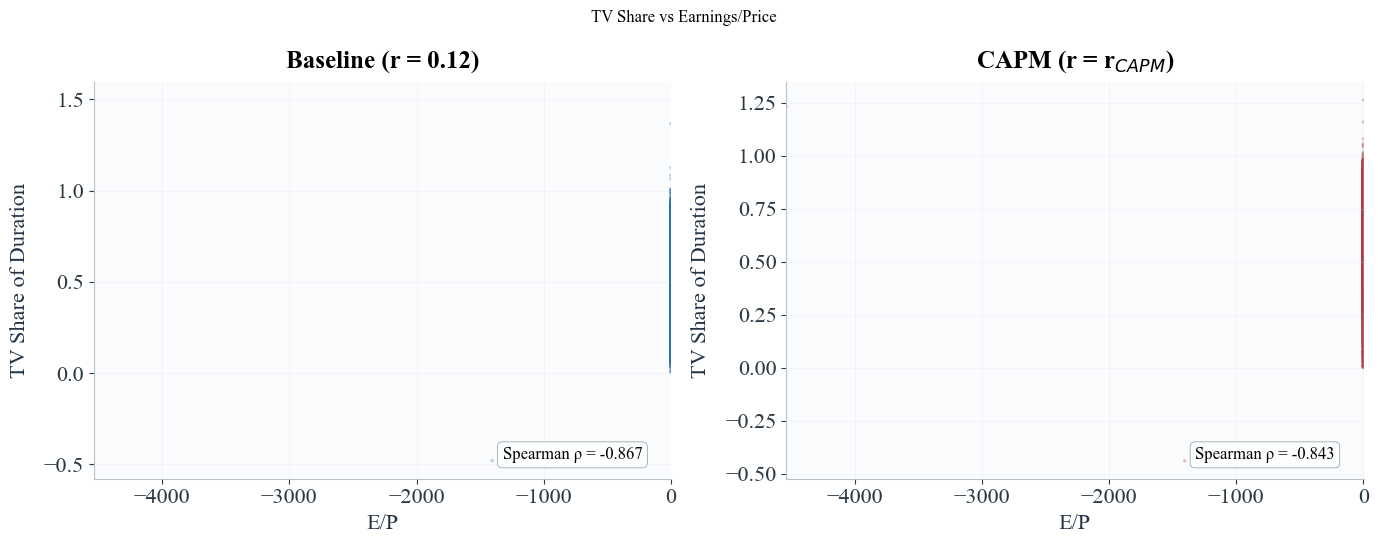

In [37]:
set_global_plot_style()

# Compute E/P for the panel
usable_tv["EP"] = usable_tv["ROE_fy1"] * usable_tv["BE"] / usable_tv["ME"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
ax.scatter(usable_tv["EP"], usable_tv["TV_share_base"],
           s=6, alpha=0.3, color=COLORS["blue"], edgecolors="none")
ax.set_xlabel("E/P")
ax.set_ylabel("TV Share of Duration")
ax.set_title("Baseline (r = 0.12)")
style_axes(ax, grid_axis="both")
# Add Spearman
from scipy.stats import spearmanr
rho_ep_b, _ = spearmanr(usable_tv["EP"].dropna(), usable_tv["TV_share_base"].dropna())
ax.annotate(f"Spearman \u03c1 = {rho_ep_b:+.3f}",
            xy=(0.95, 0.05), xycoords="axes fraction", ha="right", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["neutral"], alpha=0.8))

ax = axes[1]
ax.scatter(usable_tv["EP"], usable_tv["TV_share_capm"],
           s=6, alpha=0.3, color=COLORS["accent"], edgecolors="none")
ax.set_xlabel("E/P")
ax.set_ylabel("TV Share of Duration")
ax.set_title("CAPM (r = r$_{CAPM}$)")
style_axes(ax, grid_axis="both")
rho_ep_c, _ = spearmanr(
    usable_tv.loc[usable_tv["EP"].notna() & usable_tv["TV_share_capm"].notna(), "EP"],
    usable_tv.loc[usable_tv["EP"].notna() & usable_tv["TV_share_capm"].notna(), "TV_share_capm"])
ax.annotate(f"Spearman \u03c1 = {rho_ep_c:+.3f}",
            xy=(0.95, 0.05), xycoords="axes fraction", ha="right", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=COLORS["neutral"], alpha=0.8))

fig.suptitle("TV Share vs Earnings/Price", fontsize=16, y=1.02)
fig.tight_layout()
save_capm_figure(fig, "tv_share_vs_ep")
plt.show()

### Plot C: Duration decomposition by decile

/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_28649/1748455862.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dec_base = usable_tv.groupby("dur_decile")[["Expl_share_base", "TV_share_base"]].mean()
/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_28649/1748455862.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dec_capm = usable_tv.groupby("dur_decile")[["Expl_share_capm", "TV_share_capm"]].mean()


Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/graphs/FcstD_CAPM/tv_share_by_decile.png


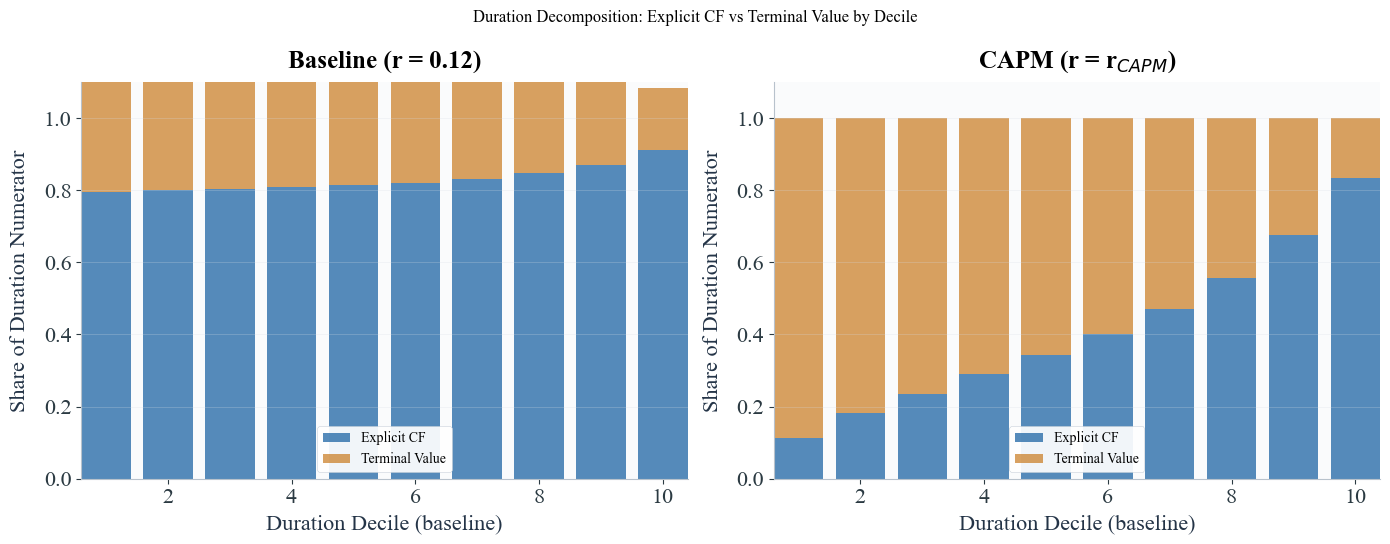

In [38]:
set_global_plot_style()

# Compute decomposition components
usable_tv["Expl_dur_base"] = usable_tv["Duration_FcstD_raw"] * usable_tv["ME"] - \
    H_TOT * usable_tv["TV_r012"] * np.exp(-0.12 * H_TOT)
usable_tv["TV_dur_base"] = H_TOT * usable_tv["TV_r012"] * np.exp(-0.12 * H_TOT)
usable_tv["Total_dur_base"] = usable_tv["Expl_dur_base"] + usable_tv["TV_dur_base"]

usable_tv["Expl_dur_capm"] = usable_tv["Duration_r_capm_raw"] * usable_tv["ME"] - \
    H_TOT * usable_tv["TV_r_capm"] * np.exp(-usable_tv["r_capm"] * H_TOT)
usable_tv["TV_dur_capm"] = H_TOT * usable_tv["TV_r_capm"] * np.exp(-usable_tv["r_capm"] * H_TOT)
usable_tv["Total_dur_capm"] = usable_tv["Expl_dur_capm"] + usable_tv["TV_dur_capm"]

# Normalize to shares
usable_tv["Expl_share_base"] = usable_tv["Expl_dur_base"] / usable_tv["Total_dur_base"]
usable_tv["Expl_share_capm"] = usable_tv["Expl_dur_capm"] / usable_tv["Total_dur_capm"]

# Decile by baseline duration
usable_tv["dur_decile"] = pd.qcut(usable_tv["Duration_FcstD_r012"], 10, labels=range(1, 11))

# Mean shares by decile
dec_base = usable_tv.groupby("dur_decile")[["Expl_share_base", "TV_share_base"]].mean()
dec_capm = usable_tv.groupby("dur_decile")[["Expl_share_capm", "TV_share_capm"]].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: Baseline
ax = axes[0]
ax.bar(dec_base.index.astype(int), dec_base["Expl_share_base"],
       color=COLORS["blue"], alpha=0.8, label="Explicit CF")
ax.bar(dec_base.index.astype(int), dec_base["TV_share_base"],
       bottom=dec_base["Expl_share_base"],
       color=COLORS["orange"], alpha=0.7, label="Terminal Value")
ax.set_xlabel("Duration Decile (baseline)")
ax.set_ylabel("Share of Duration Numerator")
ax.set_title("Baseline (r = 0.12)")
ax.set_ylim(0, 1.1)
style_axes(ax)
ax.legend(fontsize=10)

# Panel B: CAPM
ax = axes[1]
ax.bar(dec_capm.index.astype(int), dec_capm["Expl_share_capm"],
       color=COLORS["blue"], alpha=0.8, label="Explicit CF")
ax.bar(dec_capm.index.astype(int), dec_capm["TV_share_capm"],
       bottom=dec_capm["Expl_share_capm"],
       color=COLORS["orange"], alpha=0.7, label="Terminal Value")
ax.set_xlabel("Duration Decile (baseline)")
ax.set_ylabel("Share of Duration Numerator")
ax.set_title("CAPM (r = r$_{CAPM}$)")
ax.set_ylim(0, 1.1)
style_axes(ax)
ax.legend(fontsize=10)

fig.suptitle("Duration Decomposition: Explicit CF vs Terminal Value by Decile", fontsize=16, y=1.02)
fig.tight_layout()
save_capm_figure(fig, "tv_share_by_decile")
plt.show()

### Summary: TV Share Diagnostic

In [39]:
from scipy.stats import spearmanr

# Merge NpD for correlation comparison
_np_dur = np_out[["firm_id", "year", "Duration_NetPayout"]].copy()
_np_dur = _np_dur.rename(columns={"Duration_NetPayout": "Duration_NP"})
_tv_corr = usable_tv.merge(_np_dur, on=["firm_id", "year"], how="left")
_tv_corr["EP"] = _tv_corr["ROE_fy1"] * _tv_corr["BE"] / _tv_corr["ME"]
_tv_corr["BM"] = _tv_corr["BE"] / _tv_corr["ME"]

# Correlations
_mask = _tv_corr[["Duration_FcstD_r012", "Duration_FcstD_CAPM", "Duration_NP", "EP", "BM"]].notna().all(axis=1)
_cd = _tv_corr.loc[_mask]

rho_base_ep, _ = spearmanr(_cd["Duration_FcstD_r012"], _cd["EP"])
rho_capm_ep, _ = spearmanr(_cd["Duration_FcstD_CAPM"], _cd["EP"])
rho_base_bm, _ = spearmanr(_cd["Duration_FcstD_r012"], _cd["BM"])
rho_capm_bm, _ = spearmanr(_cd["Duration_FcstD_CAPM"], _cd["BM"])
rho_base_npd, _ = spearmanr(_cd["Duration_FcstD_r012"], _cd["Duration_NP"])
rho_capm_npd, _ = spearmanr(_cd["Duration_FcstD_CAPM"], _cd["Duration_NP"])

print("=" * 70)
print("TV SHARE DIAGNOSTIC SUMMARY")
print("=" * 70)

print(f"\n{'':30s}  {'Baseline (r=0.12)':>20s}  {'CAPM (r=r_capm)':>20s}")
print(f"{'TV share \u2014 mean':30s}  {usable_tv['TV_share_base'].mean():20.3f}  {usable_tv['TV_share_capm'].mean():20.3f}")
print(f"{'TV share \u2014 median':30s}  {usable_tv['TV_share_base'].median():20.3f}  {usable_tv['TV_share_capm'].median():20.3f}")
print(f"{'TV share \u2014 P10':30s}  {usable_tv['TV_share_base'].quantile(0.10):20.3f}  {usable_tv['TV_share_capm'].quantile(0.10):20.3f}")
print(f"{'TV share \u2014 P90':30s}  {usable_tv['TV_share_base'].quantile(0.90):20.3f}  {usable_tv['TV_share_capm'].quantile(0.90):20.3f}")
print(f"{'\u03c1(Duration, E/P)':30s}  {rho_base_ep:+20.3f}  {rho_capm_ep:+20.3f}")
print(f"{'\u03c1(Duration, B/M)':30s}  {rho_base_bm:+20.3f}  {rho_capm_bm:+20.3f}")
print(f"{'\u03c1(Duration, NpD)':30s}  {rho_base_npd:+20.3f}  {rho_capm_npd:+20.3f}")

print("\n" + "=" * 70)
tv_mean_base = usable_tv["TV_share_base"].mean()
tv_mean_capm = usable_tv["TV_share_capm"].mean()
print(f"DIAGNOSIS: FcstD baseline (r=0.12) derives {tv_mean_base:.0%} of its duration")
print(f"from the Terminal Value on average. This explains the \u03c1={rho_base_ep:+.2f} with")
print(f"E/P \u2014 the measure is dominated by the residual (ME - PV), which is")
print(f"mechanically linked to market equity relative to earnings.")
print(f"\nFcstD CAPM (r=r_capm) derives {tv_mean_capm:.0%} from TV, giving")
if tv_mean_capm < tv_mean_base - 0.05:
    print(f"substantially more weight to the explicit earnings forecasts.")
    print(f"This breaks the E/P redundancy (\u03c1={rho_capm_ep:+.2f}) and produces")
    print(f"a measure that more genuinely captures earnings timing.")
else:
    print(f"a similar TV share. The E/P correlation is \u03c1={rho_capm_ep:+.2f}.")
    print(f"The CAPM DR changes the ranking of firms but does not fundamentally")
    print(f"change the TV-dominated structure of the measure.")
print("=" * 70)

TV SHARE DIAGNOSTIC SUMMARY

                                   Baseline (r=0.12)       CAPM (r=r_capm)
TV share — mean                                0.513                 0.590
TV share — median                              0.525                 0.624
TV share — P10                                 0.230                 0.250
TV share — P90                                 0.773                 0.867
ρ(Duration, E/P)                              +0.812                -0.223
ρ(Duration, B/M)                              +0.500                -0.171
ρ(Duration, NpD)                              -0.285                +0.125

DIAGNOSIS: FcstD baseline (r=0.12) derives 51% of its duration
from the Terminal Value on average. This explains the ρ=+0.81 with
E/P — the measure is dominated by the residual (ME - PV), which is
mechanically linked to market equity relative to earnings.

FcstD CAPM (r=r_capm) derives 59% from TV, giving
a similar TV share. The E/P correlation is ρ=-0.22.
The CAPM DR